# **Lab: Data Pipeline 2**

## Exercise 3: Airflow data pipeline + dbt transformations

In this exercise, we will learn how to build a end to end data pipeline on Airflow.




# 1. Create an Airflow DAG to load data from csv into Postgres

**[1.1]** Make a copy of "dag_template.py" and call it "dag_exercise_3.py".

**[1.2]** Download the dataset and extract it:
https://drive.google.com/file/d/15gm_V2MIXcX3hy9CRualvSaCxC1f6oT0/view?usp=drive_link

**[1.3]** In GCP, go to Cloud Composer and click on the "DAGS" link. Then go one folder up and search for the "data" folder. In it create two folders (`dimensions` and `facts`) and inside each folder create a folder named `archive`. Finally add the dimensions csv into the `dimensions` folder and `sales_202001.csv` into the `facts` folder :

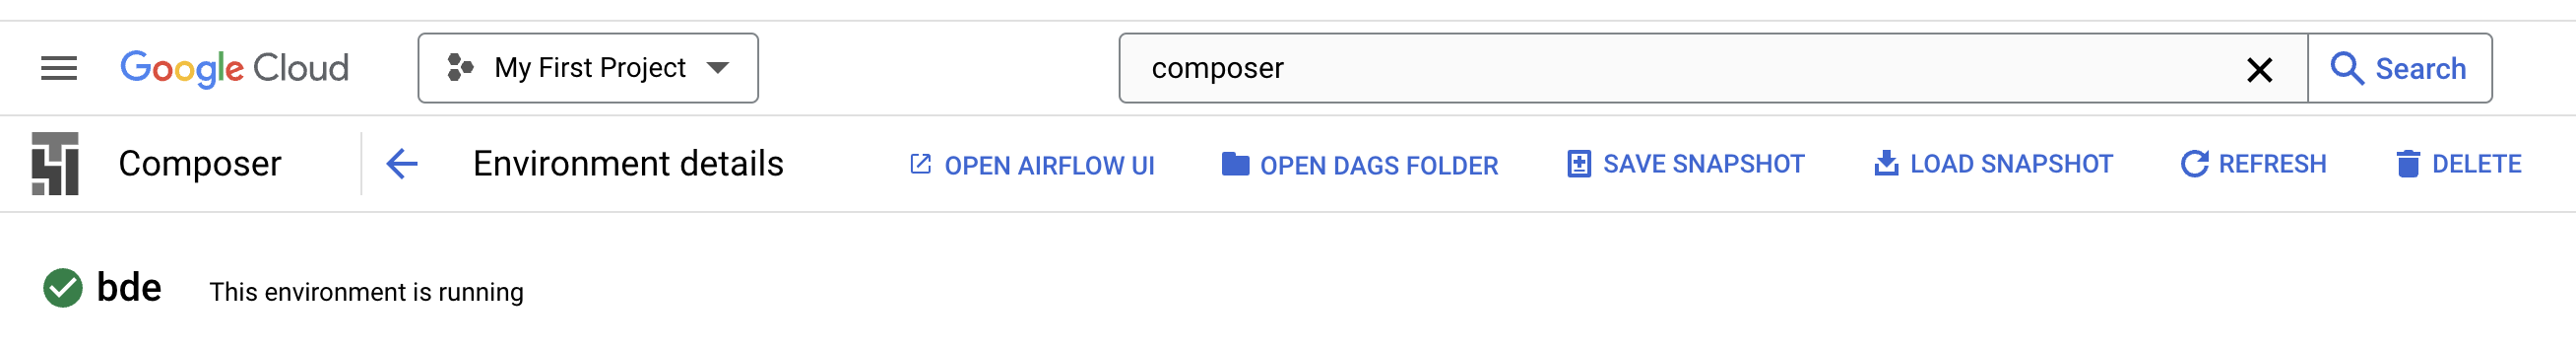

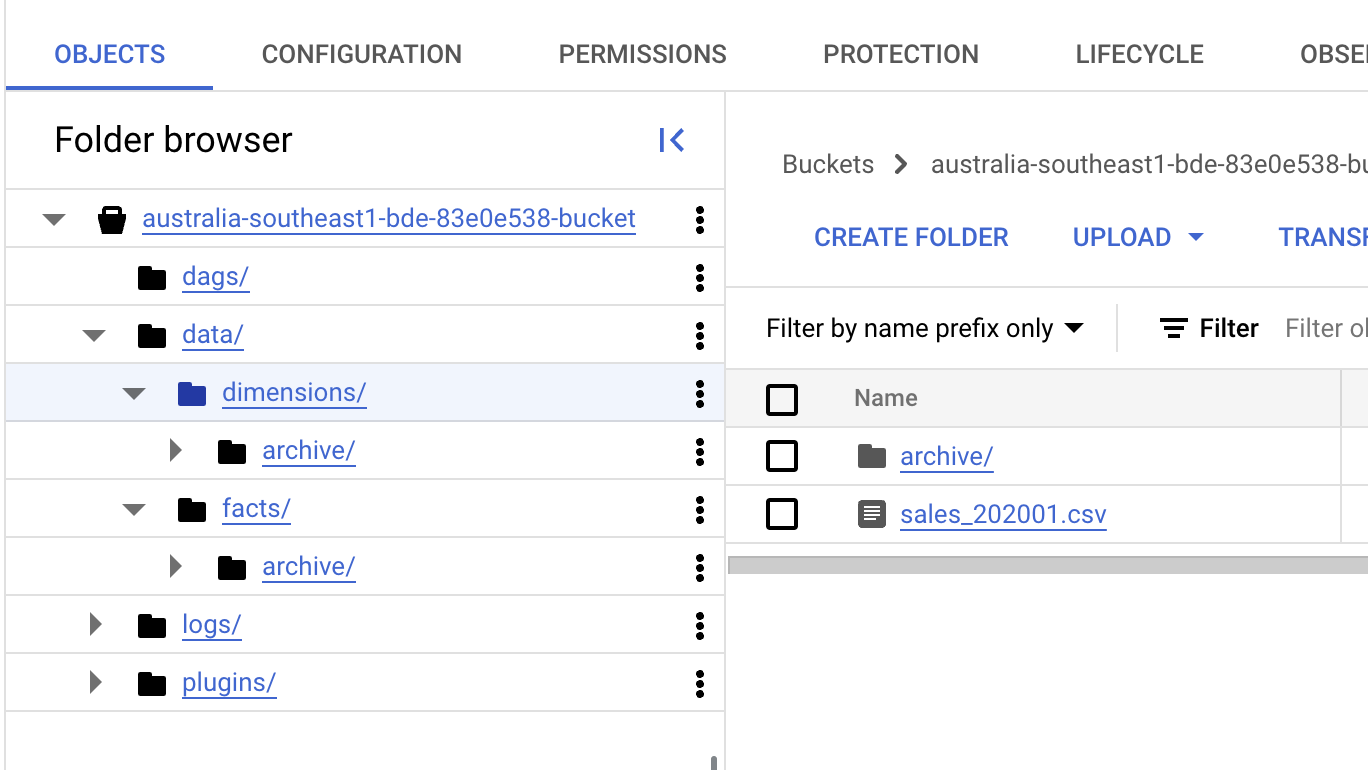

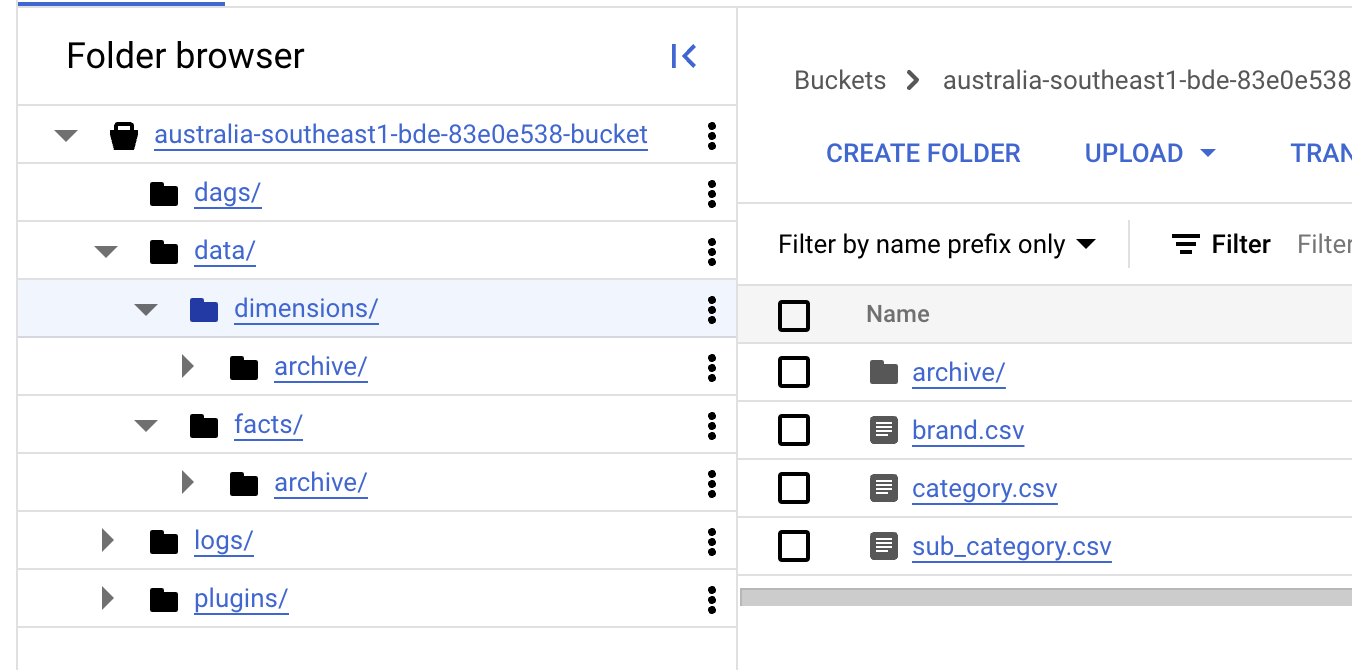

**[1.4]** Open DBeaver and connect to your GCP managed Postgres

Run the following SQL scripts:


In [ ]:
CREATE SCHEMA BRONZE;

---------------------------
-- Bronze
---------------------------

CREATE TABLE BRONZE.RAW_BRAND (
	ID INT PRIMARY KEY,
	BRAND VARCHAR NULL
);

CREATE TABLE BRONZE.RAW_CATEGORY (
	ID INT PRIMARY KEY,
	CATEGORY VARCHAR NULL
);

CREATE TABLE BRONZE.RAW_SUBCATEGORY (
	ID INT PRIMARY KEY,
	SUB_CATEGORY VARCHAR NULL
);

CREATE TABLE BRONZE.RAW_FACTS (
	ORDER_ID INT,
	DATE VARCHAR NULL,
	PRICE DECIMAL(32,2),
	BRAND_ID INT,
	CATEGORY_ID INT,
	SUBCATEGORY_ID INT
);

**[1.5]** Open "dag_exercise_3.py" copy paste the following code:







In [ ]:
import os
import logging
import requests
import pandas as pd
import numpy as np
import shutil
from datetime import datetime, timedelta
from psycopg2.extras import execute_values
from airflow import AirflowException
from airflow import DAG
from airflow.models import Variable
from airflow.operators.python_operator import PythonOperator
from airflow.providers.postgres.operators.postgres import PostgresOperator
from airflow.providers.postgres.hooks.postgres import PostgresHook

#########################################################
#
#   DAG Settings
#
#########################################################

dag_default_args = {
    'owner': 'BDE_LAB_6',
    'start_date': datetime.now() - timedelta(days=2+4),
    'email': [],
    'email_on_failure': True,
    'email_on_retry': False,
    'retries': 2,
    'retry_delay': timedelta(minutes=5),
    'depends_on_past': False,
    'wait_for_downstream': False,
}

dag = DAG(
    dag_id='exercise_3',
    default_args=dag_default_args,
    schedule_interval=None,
    catchup=True,
    max_active_runs=1,
    concurrency=5
)

#########################################################
#
#   Load Environment Variables
#
#########################################################
AIRFLOW_DATA = "/home/airflow/gcs/data"
DIMENSIONS = AIRFLOW_DATA + "/dimensions/"
FACTS = AIRFLOW_DATA + "/facts/"

#########################################################
#
#   Custom Logics for Operator
#
#########################################################

def import_load_dim_category_func(**kwargs):

    # Setup Postgres connection
    ps_pg_hook = PostgresHook(postgres_conn_id="postgres")
    conn_ps = ps_pg_hook.get_conn()

    # Check if the file exists
    category_file_path = DIMENSIONS + 'category.csv'
    if not os.path.exists(category_file_path):
        logging.info("No category.csv file found.")
        return None

    # Generate dataframe by reading the CSV file
    df = pd.read_csv(category_file_path)

    if len(df) > 0:
        col_names = ['id', 'category']
        values = df[col_names].to_dict('split')['data']
        logging.info(values)

        insert_sql = """
                    INSERT INTO bronze.raw_category(id, category)
                    VALUES %s
                    """
        result = execute_values(conn_ps.cursor(), insert_sql, values, page_size=len(df))
        conn_ps.commit()

        # Move the processed file to the archive folder
        archive_folder = os.path.join(DIMENSIONS, 'archive')
        if not os.path.exists(archive_folder):
            os.makedirs(archive_folder)
        shutil.move(category_file_path, os.path.join(archive_folder, 'category.csv'))
    return None


def import_load_dim_sub_category_func(**kwargs):

    # Setup Postgres connection
    ps_pg_hook = PostgresHook(postgres_conn_id="postgres")
    conn_ps = ps_pg_hook.get_conn()

    # Check if the file exists
    sub_category_file_path = DIMENSIONS + 'sub_category.csv'
    if not os.path.exists(sub_category_file_path):
        logging.info("No sub_category.csv file found.")
        return None

    # Generate dataframe by reading the CSV file
    df = pd.read_csv(sub_category_file_path)

    if len(df) > 0:
        col_names = ['id', 'sub_category']
        values = df[col_names].to_dict('split')['data']
        logging.info(values)

        insert_sql = """
                    INSERT INTO bronze.raw_subcategory(id, sub_category)
                    VALUES %s
                    """
        result = execute_values(conn_ps.cursor(), insert_sql, values, page_size=len(df))
        conn_ps.commit()

        # Move the processed file to the archive folder
        archive_folder = os.path.join(DIMENSIONS, 'archive')
        if not os.path.exists(archive_folder):
            os.makedirs(archive_folder)
        shutil.move(sub_category_file_path, os.path.join(archive_folder, 'sub_category.csv'))
    return None


def import_load_dim_brand_func(**kwargs):

    # Setup Postgres connection
    ps_pg_hook = PostgresHook(postgres_conn_id="postgres")
    conn_ps = ps_pg_hook.get_conn()

    # Check if the file exists
    brand_file_path = DIMENSIONS + 'brand.csv'
    if not os.path.exists(brand_file_path):
        logging.info("No brand.csv file found.")
        return None

    # Generate dataframe by reading the CSV file
    df = pd.read_csv(brand_file_path)

    if len(df) > 0:
        col_names = ['id', 'brand']
        values = df[col_names].to_dict('split')['data']
        logging.info(values)

        insert_sql = """
                    INSERT INTO bronze.raw_brand(id, brand)
                    VALUES %s
                    """
        result = execute_values(conn_ps.cursor(), insert_sql, values, page_size=len(df))
        conn_ps.commit()

        # Move the processed file to the archive folder
        archive_folder = os.path.join(DIMENSIONS, 'archive')
        if not os.path.exists(archive_folder):
            os.makedirs(archive_folder)
        shutil.move(brand_file_path, os.path.join(archive_folder, 'brand.csv'))
    return None


def import_load_facts_func(**kwargs):

    # Setup Postgres connection
    ps_pg_hook = PostgresHook(postgres_conn_id="postgres")
    conn_ps = ps_pg_hook.get_conn()

    # Get all files with '.csv' extension in the FACTS directory
    filelist = [k for k in os.listdir(FACTS) if '.csv' in k]

    # Check if there are any files to process
    if len(filelist) == 0:
        logging.info("No CSV files found in the FACTS directory.")
        return None  # Exit gracefully if no files are found

    # Generate dataframe by combining all files
    df = pd.concat([pd.read_csv(os.path.join(FACTS, fname)) for fname in filelist], ignore_index=True)

    if len(df) > 0:
        col_names = ['date', 'order_id', 'category_id', 'subcategory_id', 'brand_id', 'price']
        values = df[col_names].to_dict('split')['data']
        logging.info(values)

        insert_sql = """
                    INSERT INTO bronze.raw_facts(date, order_id, category_id, subcategory_id, brand_id, price)
                    VALUES %s
                    """
        result = execute_values(conn_ps.cursor(), insert_sql, values, page_size=len(df))
        conn_ps.commit()

        # Move processed files to the archive folder
        archive_folder = os.path.join(FACTS, 'archive')
        if not os.path.exists(archive_folder):
            os.makedirs(archive_folder)

        for fname in filelist:
            shutil.move(os.path.join(FACTS, fname), os.path.join(archive_folder, fname))
    return None

#########################################################
#
#   DAG Operator Setup
#
#########################################################

import_load_dim_category_task = PythonOperator(
    task_id="import_load_dim_category_id",
    python_callable=import_load_dim_category_func,
    provide_context=True,
    dag=dag
)

import_load_dim_sub_category_task = PythonOperator(
    task_id="import_load_dim_sub_category_id",
    python_callable=import_load_dim_sub_category_func,
    provide_context=True,
    dag=dag
)

import_load_dim_brand_task = PythonOperator(
    task_id="import_load_dim_brand_id",
    python_callable=import_load_dim_brand_func,
    provide_context=True,
    dag=dag
)

import_load_facts_task = PythonOperator(
    task_id="import_load_facts_id",
    python_callable=import_load_facts_func,
    provide_context=True,
    dag=dag
)

# Task Dependencies
[import_load_dim_category_task, import_load_dim_sub_category_task, import_load_dim_brand_task] >> import_load_facts_task


**[1.6]** Go to your Cloud Composer "DAGS" folder and upload dag_exercise_3.py in it. Then trigger and run the DAG.




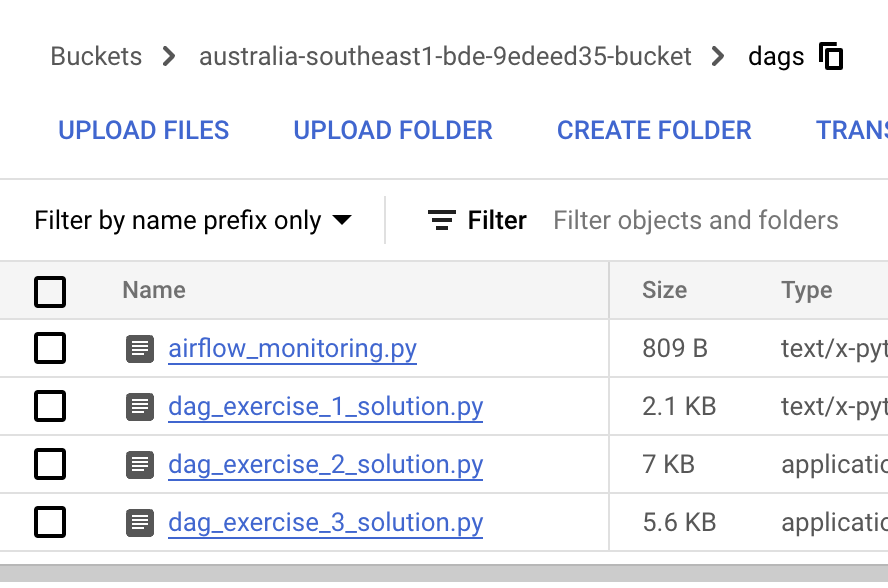

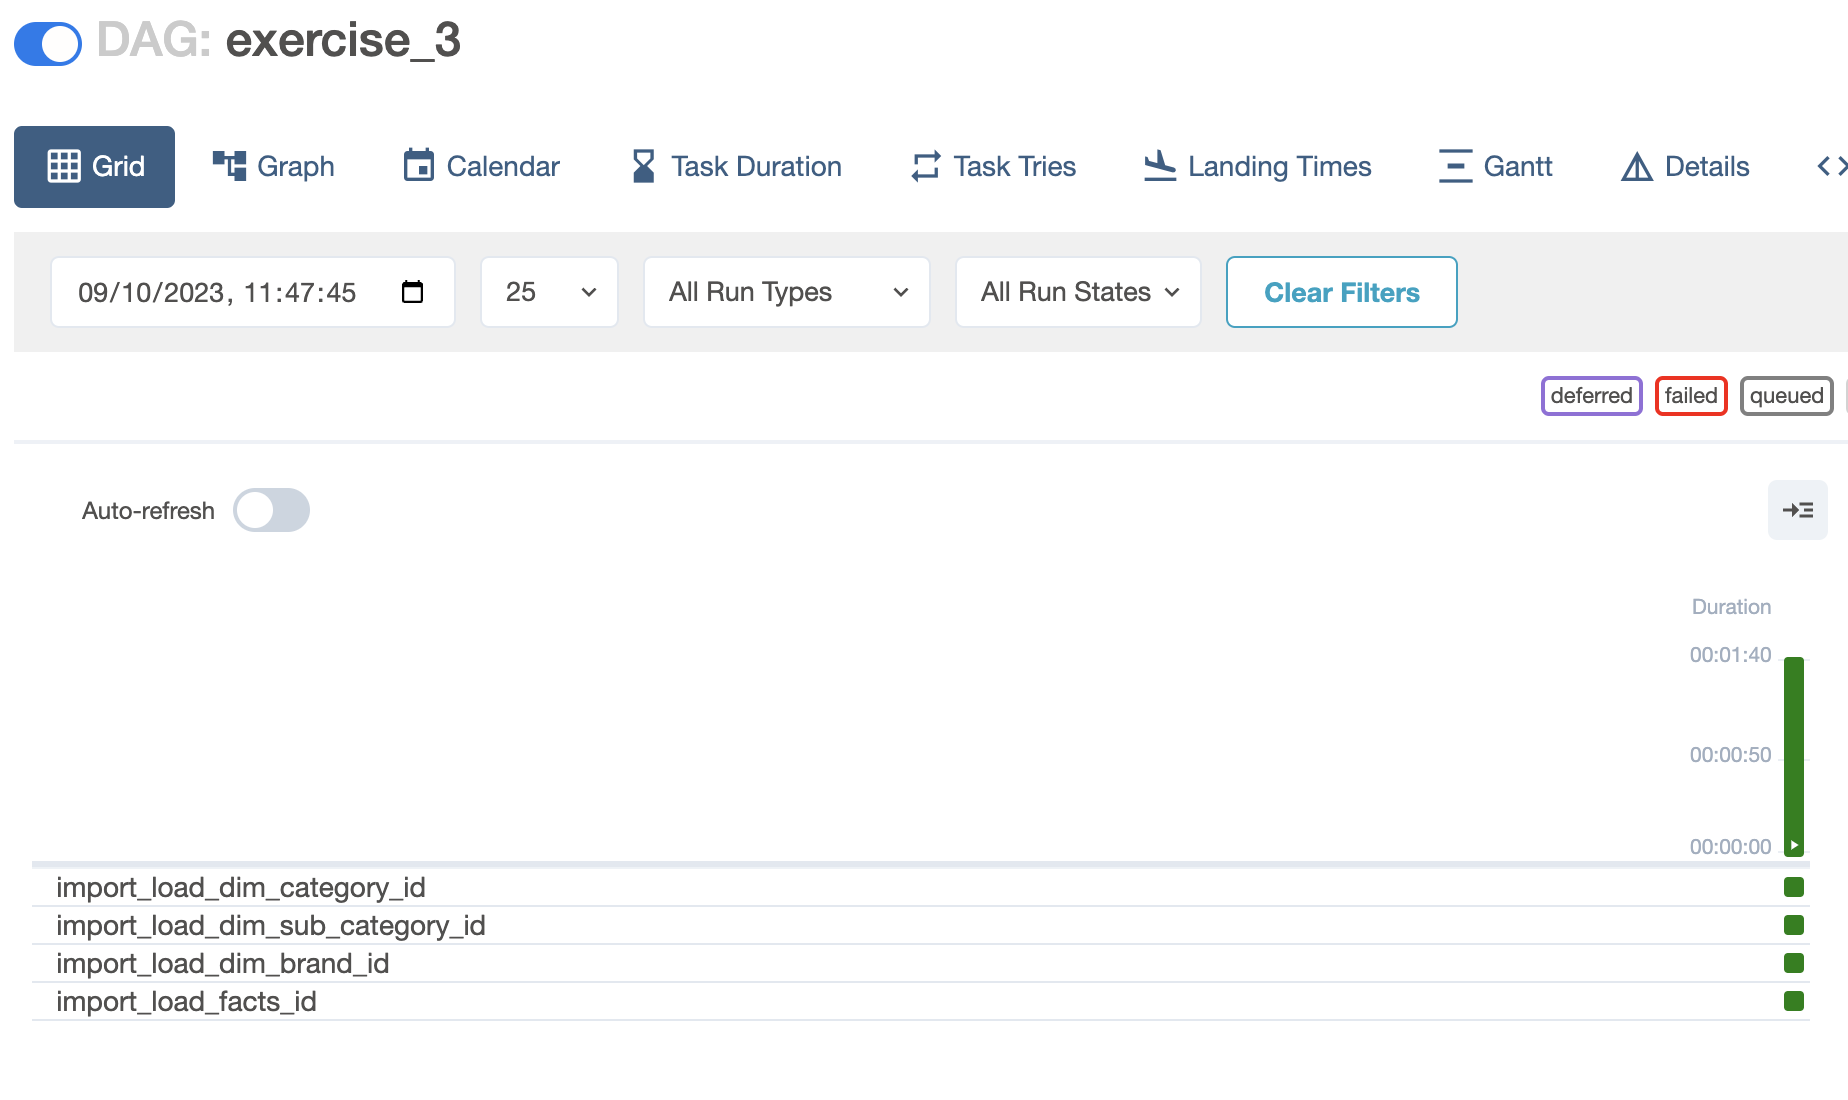

**[1.7]** On DBeaver, connect to Postgres and check that the 4 tables has been loaded with data:

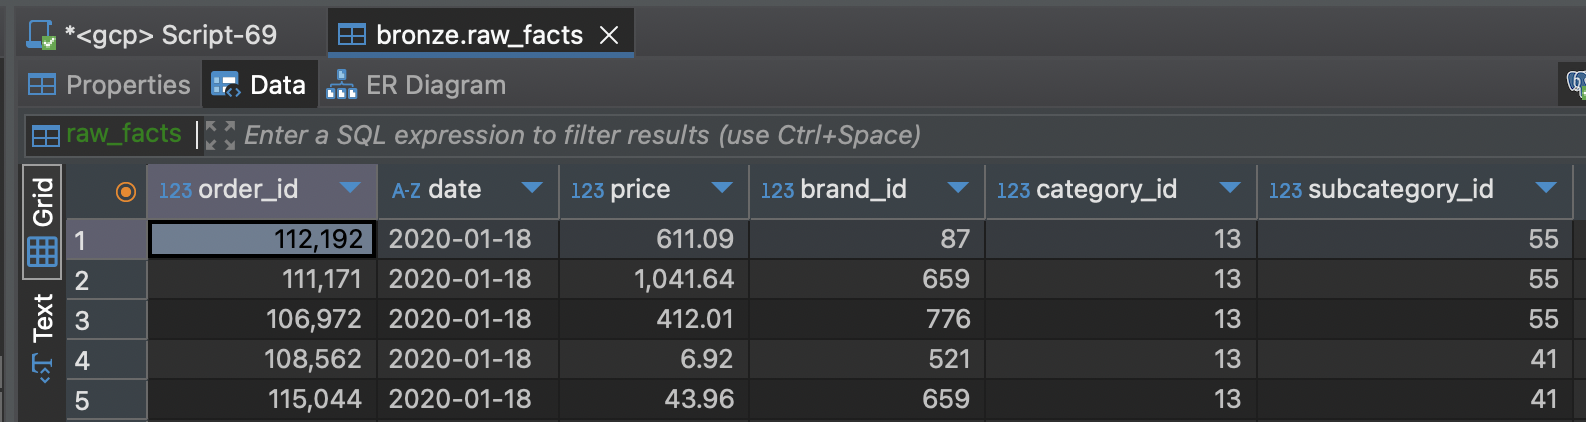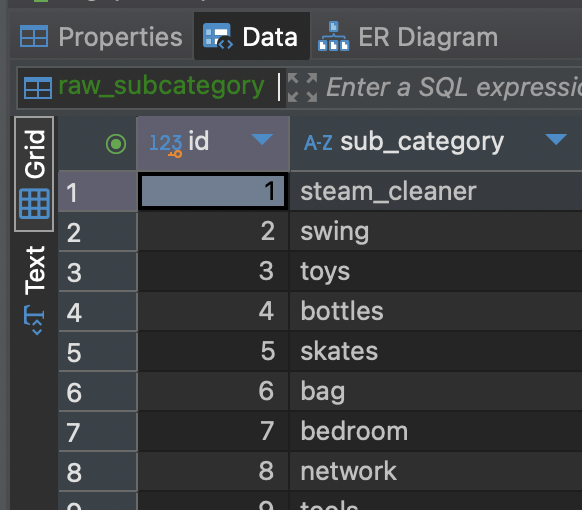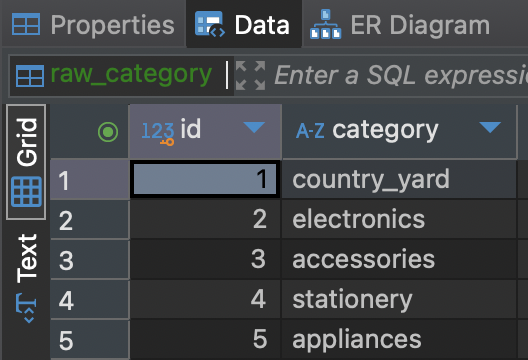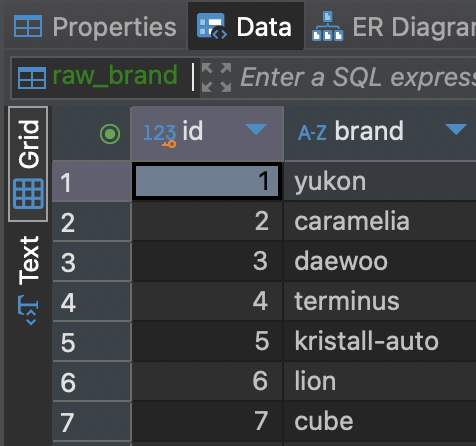

[1.8] Go to your Cloud Composer "DAGS" folder and check that the csv files are not inside the archive `folder`:

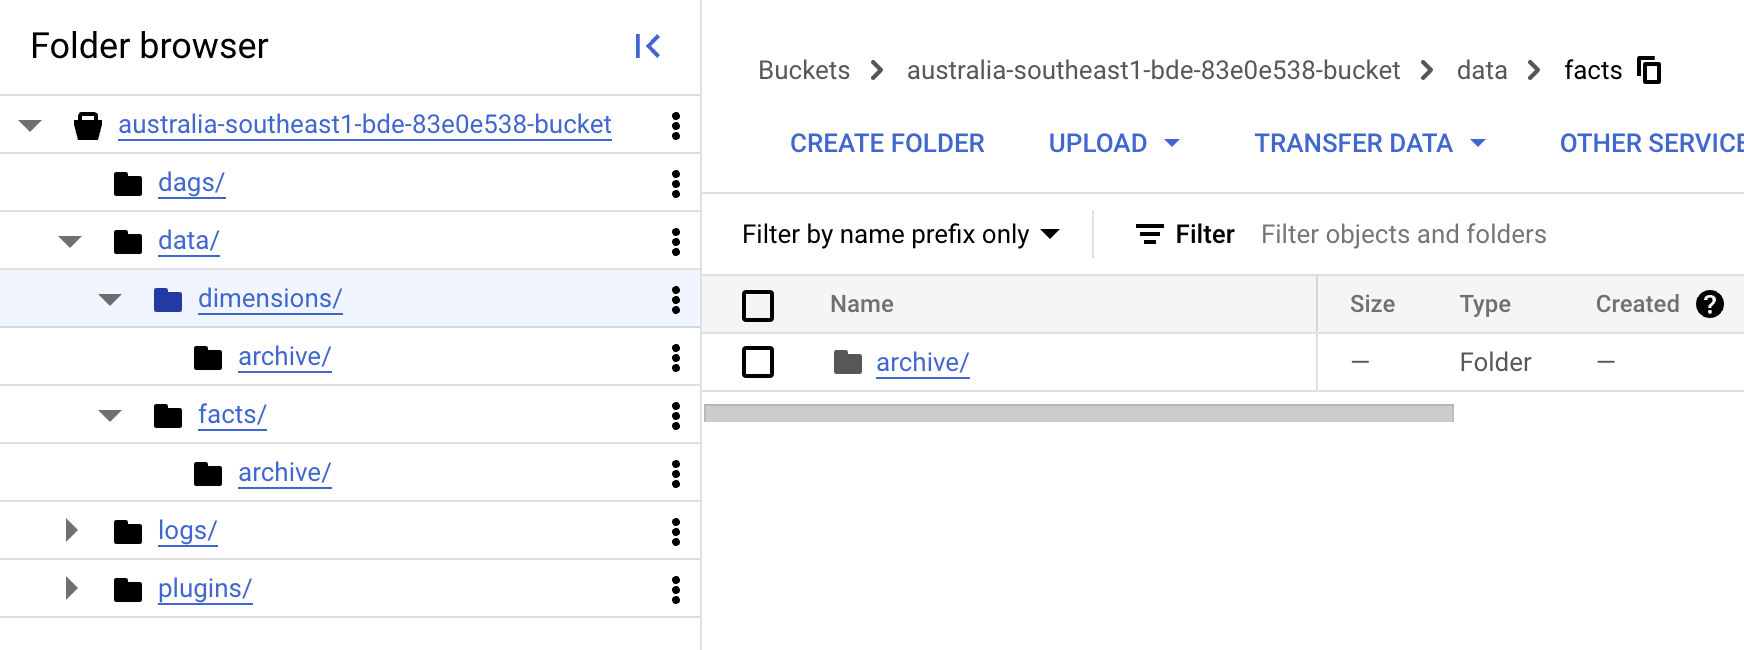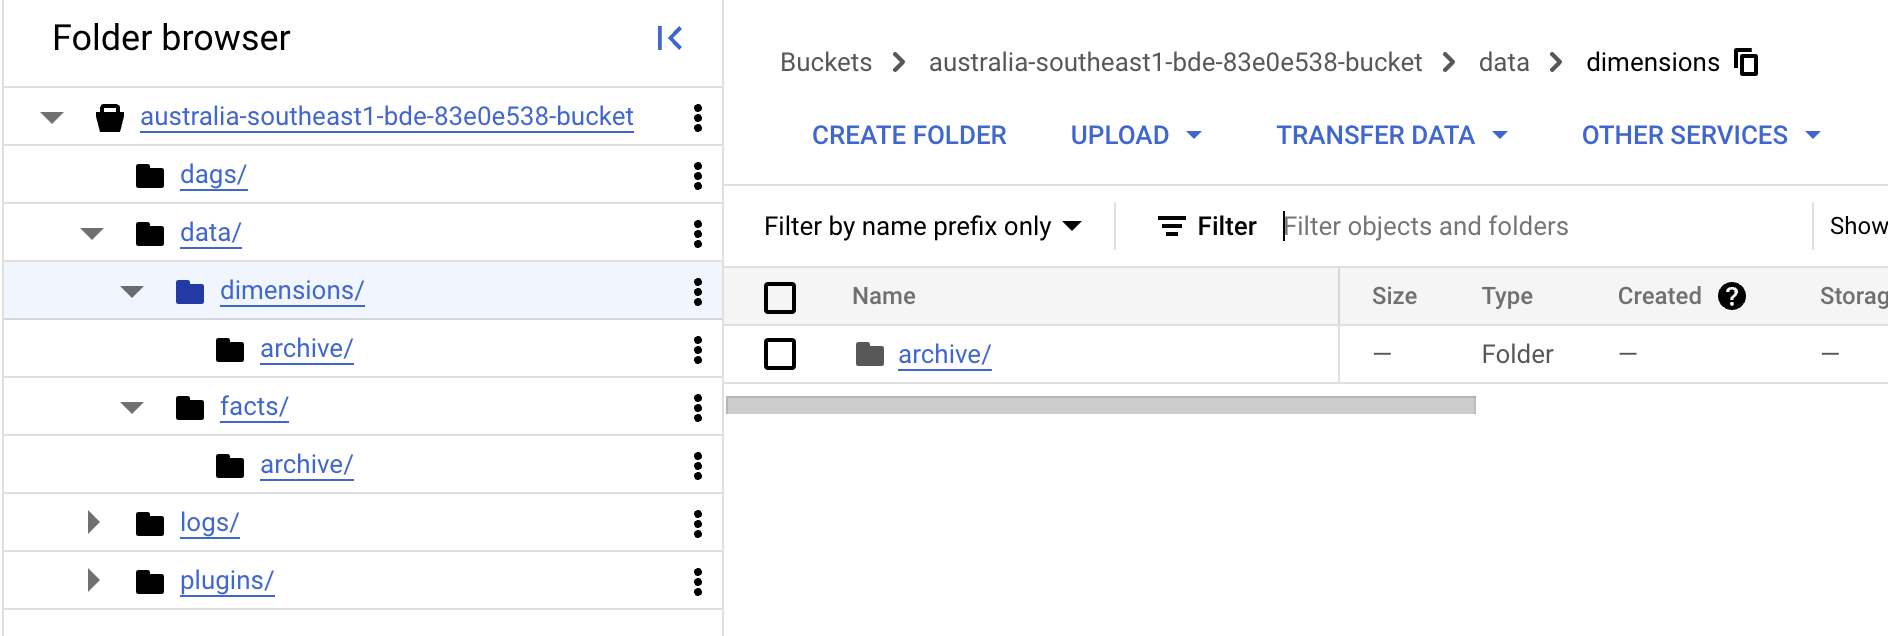

# 2. Set up the dbt project

**[2.1]** On Dbt Cloud create a new file named `packages.yml` and put the code below in it then save it:

In [ ]:
packages:
  - package: dbt-labs/dbt_utils
    version: 1.1.1

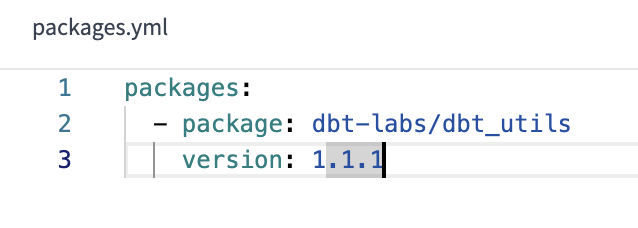

**[2.2]** Go to the `dbt_project.yml` file and replace the existing code with the one below:

In [ ]:
name: "bde_lab_6"
version: "1.0.0"
config-version: 2

profile: "default"

model-paths: ["models"]
analysis-paths: ["analyses"]
test-paths: ["tests"]
seed-paths: ["seeds"]
macro-paths: ["macros"]
snapshot-paths: ["snapshots"]

target-path: "target" # directory which will store compiled SQL files
clean-targets: # directories to be removed by `dbt clean`
  - "target"
  - "dbt_packages"

models:
  bde_lab_6:
    bronze:
      +materialized: table
      +schema: bronze
    silver:
      +materialized: table
      +schema: silver
    gold:
      star:
        +materialized: table
        +schema: gold
      mart:
        +materialized: view
        +schema: gold
snapshots:
  bde_lab_6:
    +schema: silver


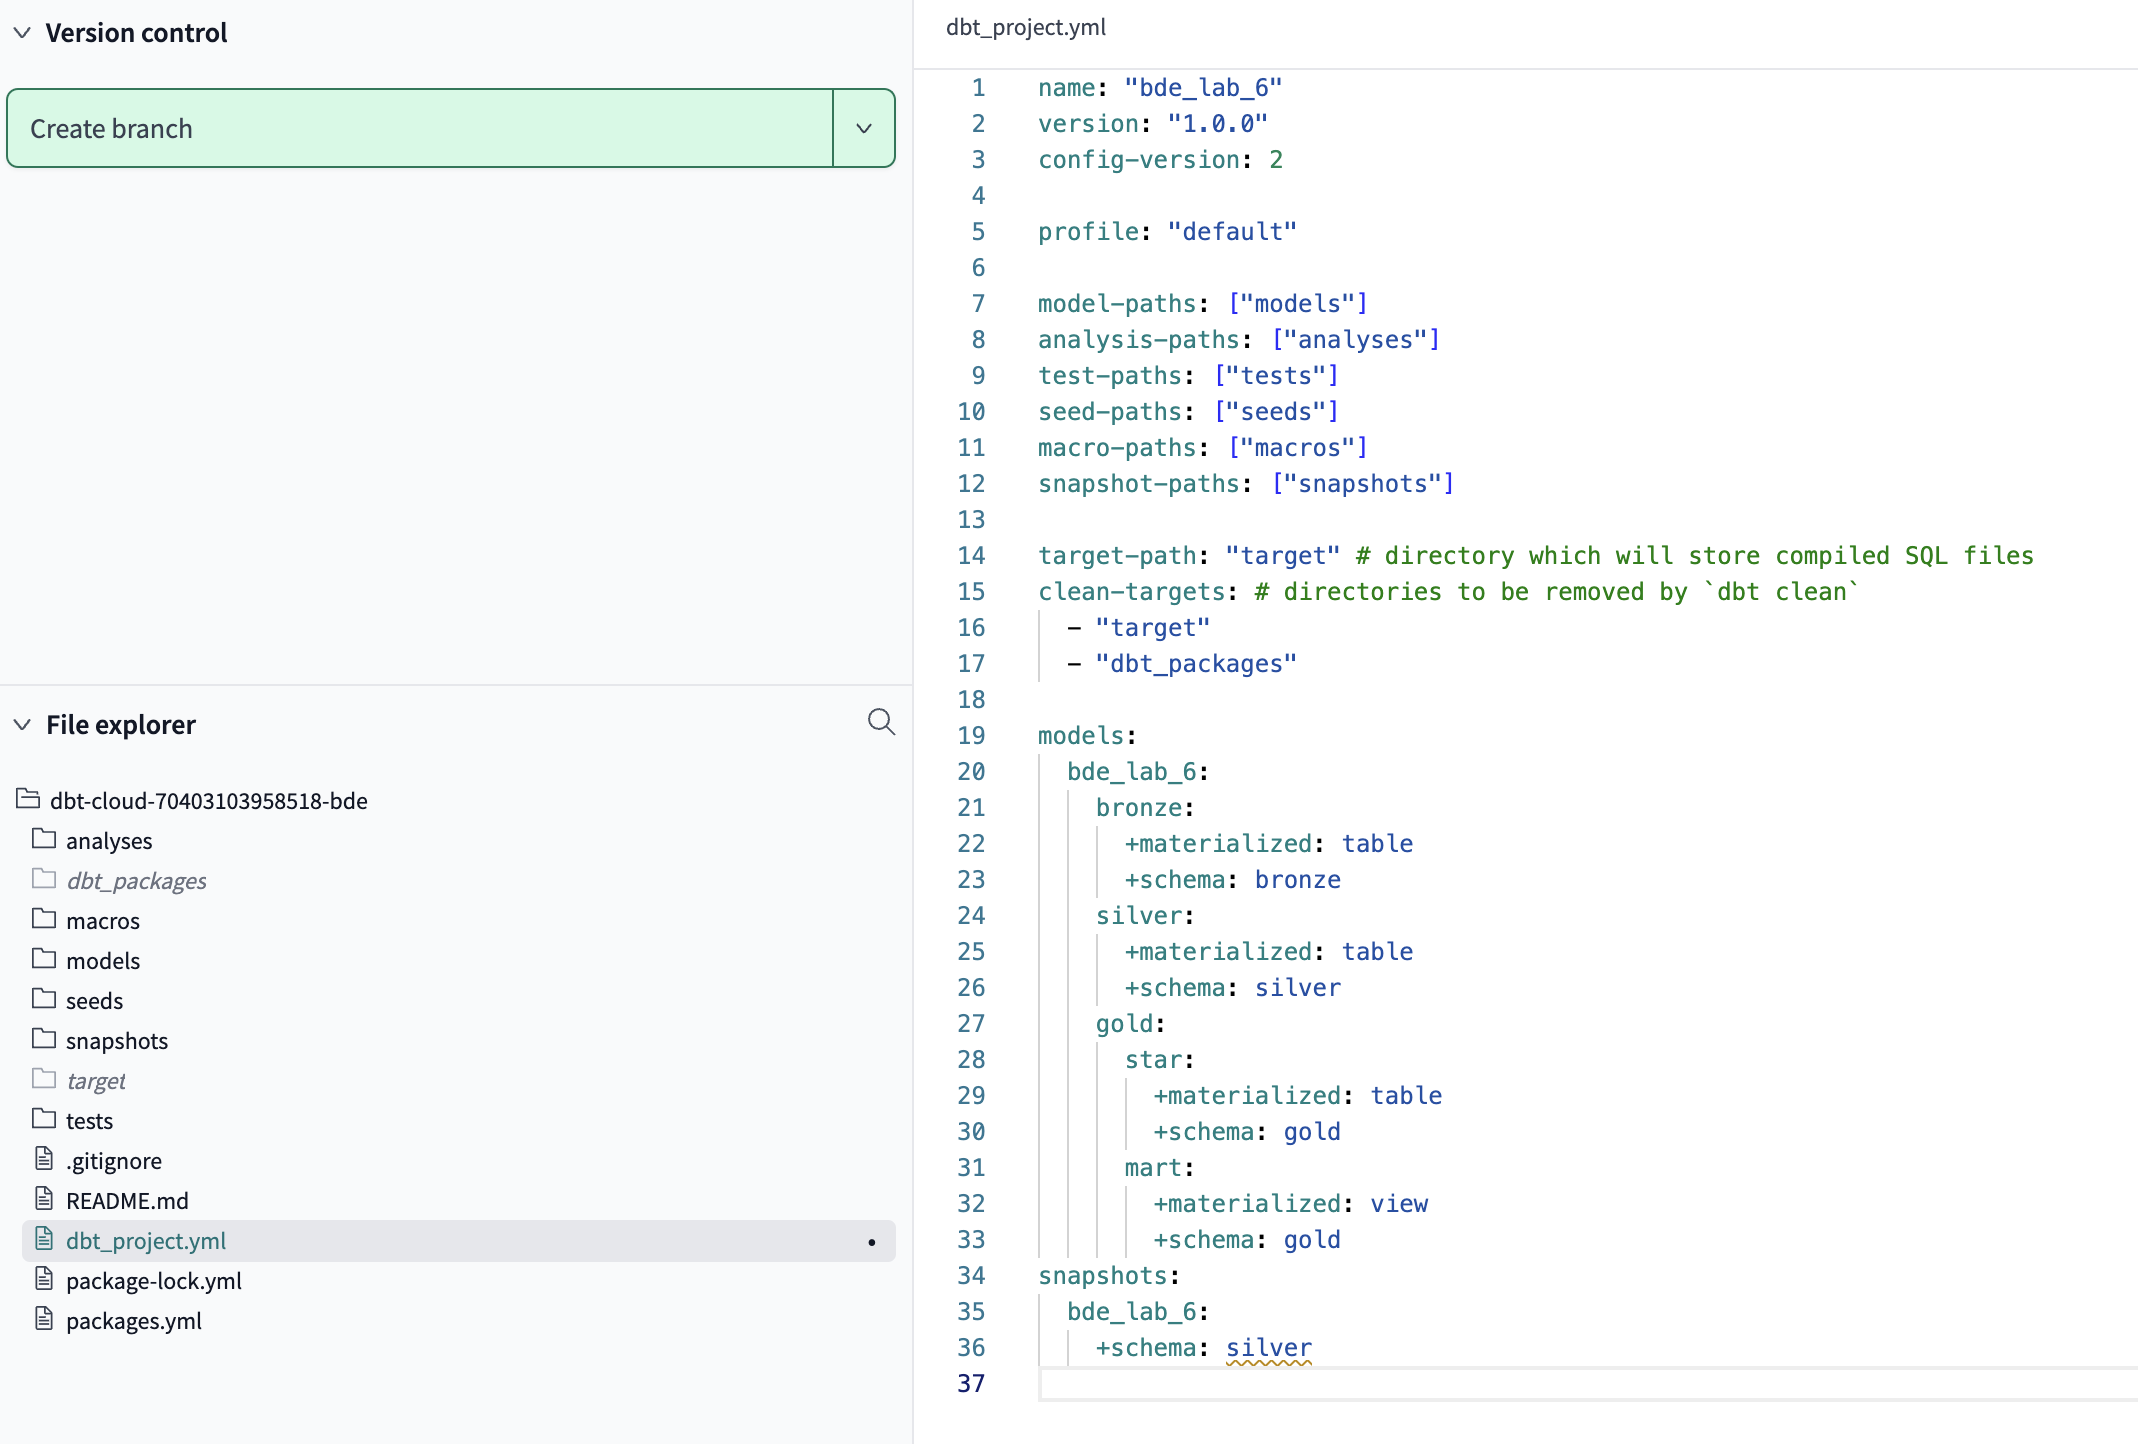

**[2.3]**In the "macros" folder, create a new files named `generate_schema_name.sql` and put the code below in it then save it:

In [ ]:
{% macro generate_schema_name(custom_schema_name, node) -%}
    {%- set default_schema = target.schema -%}

    {%- if target.name == 'prod' -%}
        {%- if custom_schema_name is none -%}
            {{ default_schema }}
        {%- else -%}
            {{ custom_schema_name | trim }}
        {%- endif -%}
    {%- else -%}
        {{ default_schema }}_{{ custom_schema_name | trim }}
    {%- endif -%}

{%- endmacro %}

**[2.4]** Run the command `dbt deps` to in install the packaged specified in the `packages.yml` file

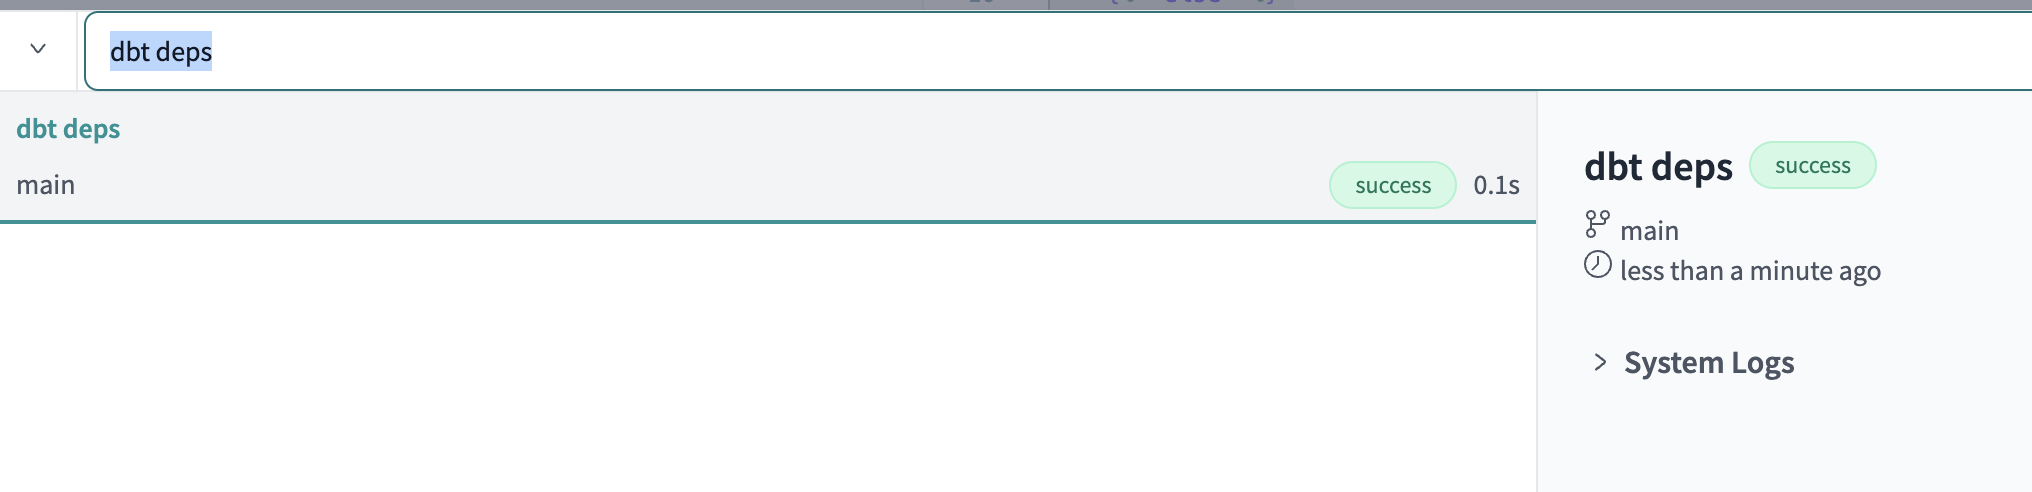

# 3. Create the dbt transformations - Bronze Layer

**[3.1]** In the "model" folder, create a new files named "sources.yml" and put the code below in it then save it:

In [ ]:
sources:
  - name: raw
    description: Raw data from CSV files
    database: postgres
    schema: bronze

    tables:
      - name: raw_brand
      - name: raw_category
      - name: raw_subcategory
      - name: raw_facts

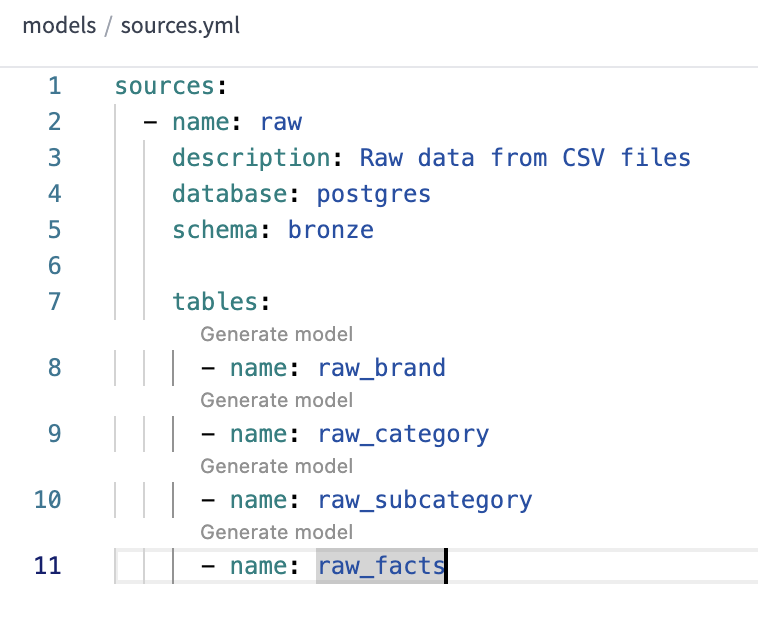

**[3.2]** Delete the "example" folder from the "model" folder then create the following folders:



*   `bronze`
*   `silver`
*   `gold`

Inside `gold` create two folders:
*   `mart`
*   `star`





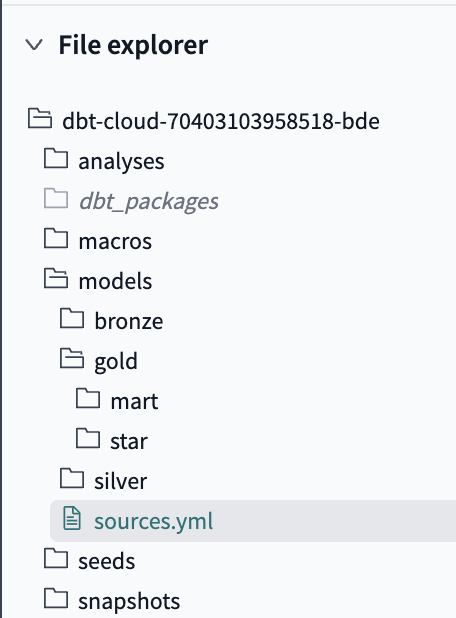

**[3.3]** In the `bronze` folder create a new file named `b_brand.sql` with:





In [ ]:
{{
    config(
        unique_key='id',
        alias='brand'
    )
}}

select * from {{ source('raw', 'raw_brand') }}

**[3.4]** Do the same with the two other dimensions tables





In [ ]:
{{
    config(
        unique_key='id',
        alias='category'
    )
}}

select * from {{ source('raw', 'raw_category') }}

In [ ]:
{{
    config(
        unique_key='id',
        alias='sub_category'
    )
}}

select * from {{ source('raw', 'raw_subcategory') }}

**[3.5]** In the `bronze` folder create a new file named `b_facts.sql` with:





In [ ]:
{{
    config(
        unique_key='transaction_id',
        alias='facts'
    )
}}

select
{{ dbt_utils.generate_surrogate_key(['order_id', 'date', 'brand_id', 'category_id','subcategory_id']) }} as transaction_id
, *
from {{ source('raw', 'raw_facts') }}

# 4. Create the dbt transformations - Silver Layer

**[4.1]** In the `silver` folder create a new file named `s_orders.sql` with:





In [ ]:
{{
    config(
        unique_key='transaction_id',
        alias='facts'
    )
}}

with

source  as (

    select * from {{ ref('b_facts') }}

),

renamed as (
    select
        transaction_id,
        order_id,
        to_date(date,'YY/MM/DD')  as date,
        category_id,
        subcategory_id as sub_category_id,
        brand_id,
        price
    from source
)

select * from renamed

**[4.2]** In the `snpshhot` folder create a new file named `brand_snapshot.sql` with:





In [ ]:
{% snapshot brand_snapshot %}

{{
        config(
          strategy='check',
          unique_key='brand_id',
          check_cols=['brand_id', 'brand_description'],
          alias='brand'
        )
    }}

select
    id as brand_id,
    brand as brand_description
from {{ ref('b_brand') }}

{% endsnapshot %}

**[4.3]** In the `snpshhot` folder create a new file named `category_snapshot.sql` with:





In [ ]:
{% snapshot category_snapshot %}

{{
        config(
          strategy='check',
          unique_key='category_id',
          check_cols=['category_id', 'category_description'],
          alias='category'
        )
    }}

select
    id as category_id,
    category as category_description
from {{ ref('b_category') }}

{% endsnapshot %}

**[4.4]** In the `snpshhot` folder create a new file named `sub_category_snapshot.sql` with:





In [ ]:
{% snapshot sub_category_snapshot %}

{{
        config(
          strategy='check',
          unique_key='sub_category_id',
          check_cols=['sub_category_id', 'sub_category_description'],
          alias='sub_category'
        )
    }}

select
    id as sub_category_id,
    sub_category as sub_category_description
from {{ ref('b_sub_category') }}

{% endsnapshot %}

As our snpashots tables doesn't have a timestamp field we can only check the updates on a list of columns. If we had a timestamp field we could have use it as another way to detect changes. More details here (https://docs.getdbt.com/reference/resource-configs/strategy).

# 5. Create the dbt transformations - Gold Layer - Star Schema

**[5.1]** In the `star` folder under `gold` create a new file named `g_dim_brand.sql` with:





In [ ]:
{{
    config(
        unique_key='brand_id',
        alias='dim_brand'
    )
}}

with

source  as (

    select * from {{ ref('brand_snapshot') }}

),

cleaned as (
    select
        brand_id,
        brand_description,
        case when dbt_valid_from = (select min(dbt_valid_from) from source) then '1900-01-01'::timestamp else dbt_valid_from end as valid_from,
        dbt_valid_to as valid_to
    from source
),

unknown as (
    select
        0 as brand_id,
        'unknown' as brand_description,
        '1900-01-01'::timestamp  as valid_from,
        null::timestamp as valid_to

)
select * from unknown
union all
select * from cleaned

**[5.2]** Create a new file named `g_dim_category.sql` with:





In [ ]:
{{
    config(
        unique_key='category_id',
        alias='dim_category'
    )
}}

with

source  as (

    select * from {{ ref('category_snapshot') }}

),

cleaned as (
    select
        category_id,
        category_description,
        case when dbt_valid_from = (select min(dbt_valid_from) from source) then '1900-01-01'::timestamp else dbt_valid_from end as valid_from,
        dbt_valid_to as valid_to
    from source
),

unknown as (
    select
        0 as category_id,
        'unknown' as category_description,
        '1900-01-01'::timestamp  as valid_from,
        null::timestamp as valid_to

)
select * from unknown
union all
select * from cleaned

**[5.3]** Create a new file named `g_dim_sub_category.sql` with:





In [ ]:
{{
    config(
        unique_key='sub_category_id',
        alias='dim_subcategory'
    )
}}

with

source  as (

    select * from {{ ref('sub_category_snapshot') }}

),

cleaned as (
    select
        sub_category_id,
        sub_category_description,
        case when dbt_valid_from = (select min(dbt_valid_from) from source) then '1900-01-01'::timestamp else dbt_valid_from end as valid_from,
        dbt_valid_to as valid_to
    from source
),

unknown as (
    select
        0 as sub_category_id,
        'unknown' as sub_category_description,
        '1900-01-01'::timestamp  as valid_from,
        null::timestamp as valid_to

)
select * from unknown
union all
select * from cleaned

**[5.4]** Create a new file named `g_fact_orders.sql` with:





In [ ]:
{{
    config(
        unique_key='order_id',
        alias='fact_orders'
    )
}}

select
	order_id,
	date,
	case when brand_id in (select distinct brand_id from {{ ref('g_dim_brand') }}) then brand_id else 0 end as brand_id,
	case when category_id in (select distinct category_id from {{ ref('g_dim_category') }}) then category_id else 0 end as category_id,
	case when sub_category_id in (select distinct sub_category_id from {{ ref('g_dim_sub_category') }}) then sub_category_id else 0 end as sub_category_id,
	price
from {{ ref('s_orders') }}

# 6. Create the dbt transformations - Gold Layer - Mart Schema

**[6.1]** In the `mart` folder under `gold` create a new file named `g_monthly_agg_brand.sql` with:





In [ ]:
{{
    config(
        alias='monthly_aggregation_by_brand'
    )
}}

select
date_trunc('month', date)::date as month,
b.brand_description,
count(distinct order_id) as total_orders,
sum(price) as total_sales
from {{ ref('g_fact_orders') }} a
left join {{ ref('g_dim_brand') }} b  on a.brand_id = b.brand_id and a.date::timestamp >= b.valid_from and a.date::timestamp < coalesce(b.valid_to, '9999-12-31'::timestamp)
group by 1,2

**[6.2]** Create a new file named `g_monthly_agg_category.sql` with:





In [ ]:
{{
    config(
        alias='monthly_aggregation_by_category'
    )
}}

select
date_trunc('month', date)::date as month,
b.category_description,
count(distinct order_id) as total_orders,
sum(price) as total_sales
from {{ ref('g_fact_orders') }} a
left join {{ ref('g_dim_category') }} b  on a.category_id = b.category_id and a.date::timestamp >= b.valid_from and a.date::timestamp < coalesce(b.valid_to, '9999-12-31'::timestamp)
group by 1,2

**[6.3]** Create a new file named `g_monthly_agg_sub_category.sql` with:





In [ ]:
{{
    config(
        alias='monthly_aggregation_by_sub_category'
    )
}}

select
date_trunc('month', date)::date as month,
b.sub_category_description,
count(distinct order_id) as total_orders,
sum(price) as total_sales
from {{ ref('g_fact_orders') }} a
left join {{ ref('g_dim_sub_category') }} b  on a.sub_category_id = b.sub_category_id and a.date::timestamp >= b.valid_from and a.date::timestamp < coalesce(b.valid_to, '9999-12-31'::timestamp)
group by 1,2

**[6.4]** Save all files then run the command: `dbt build`

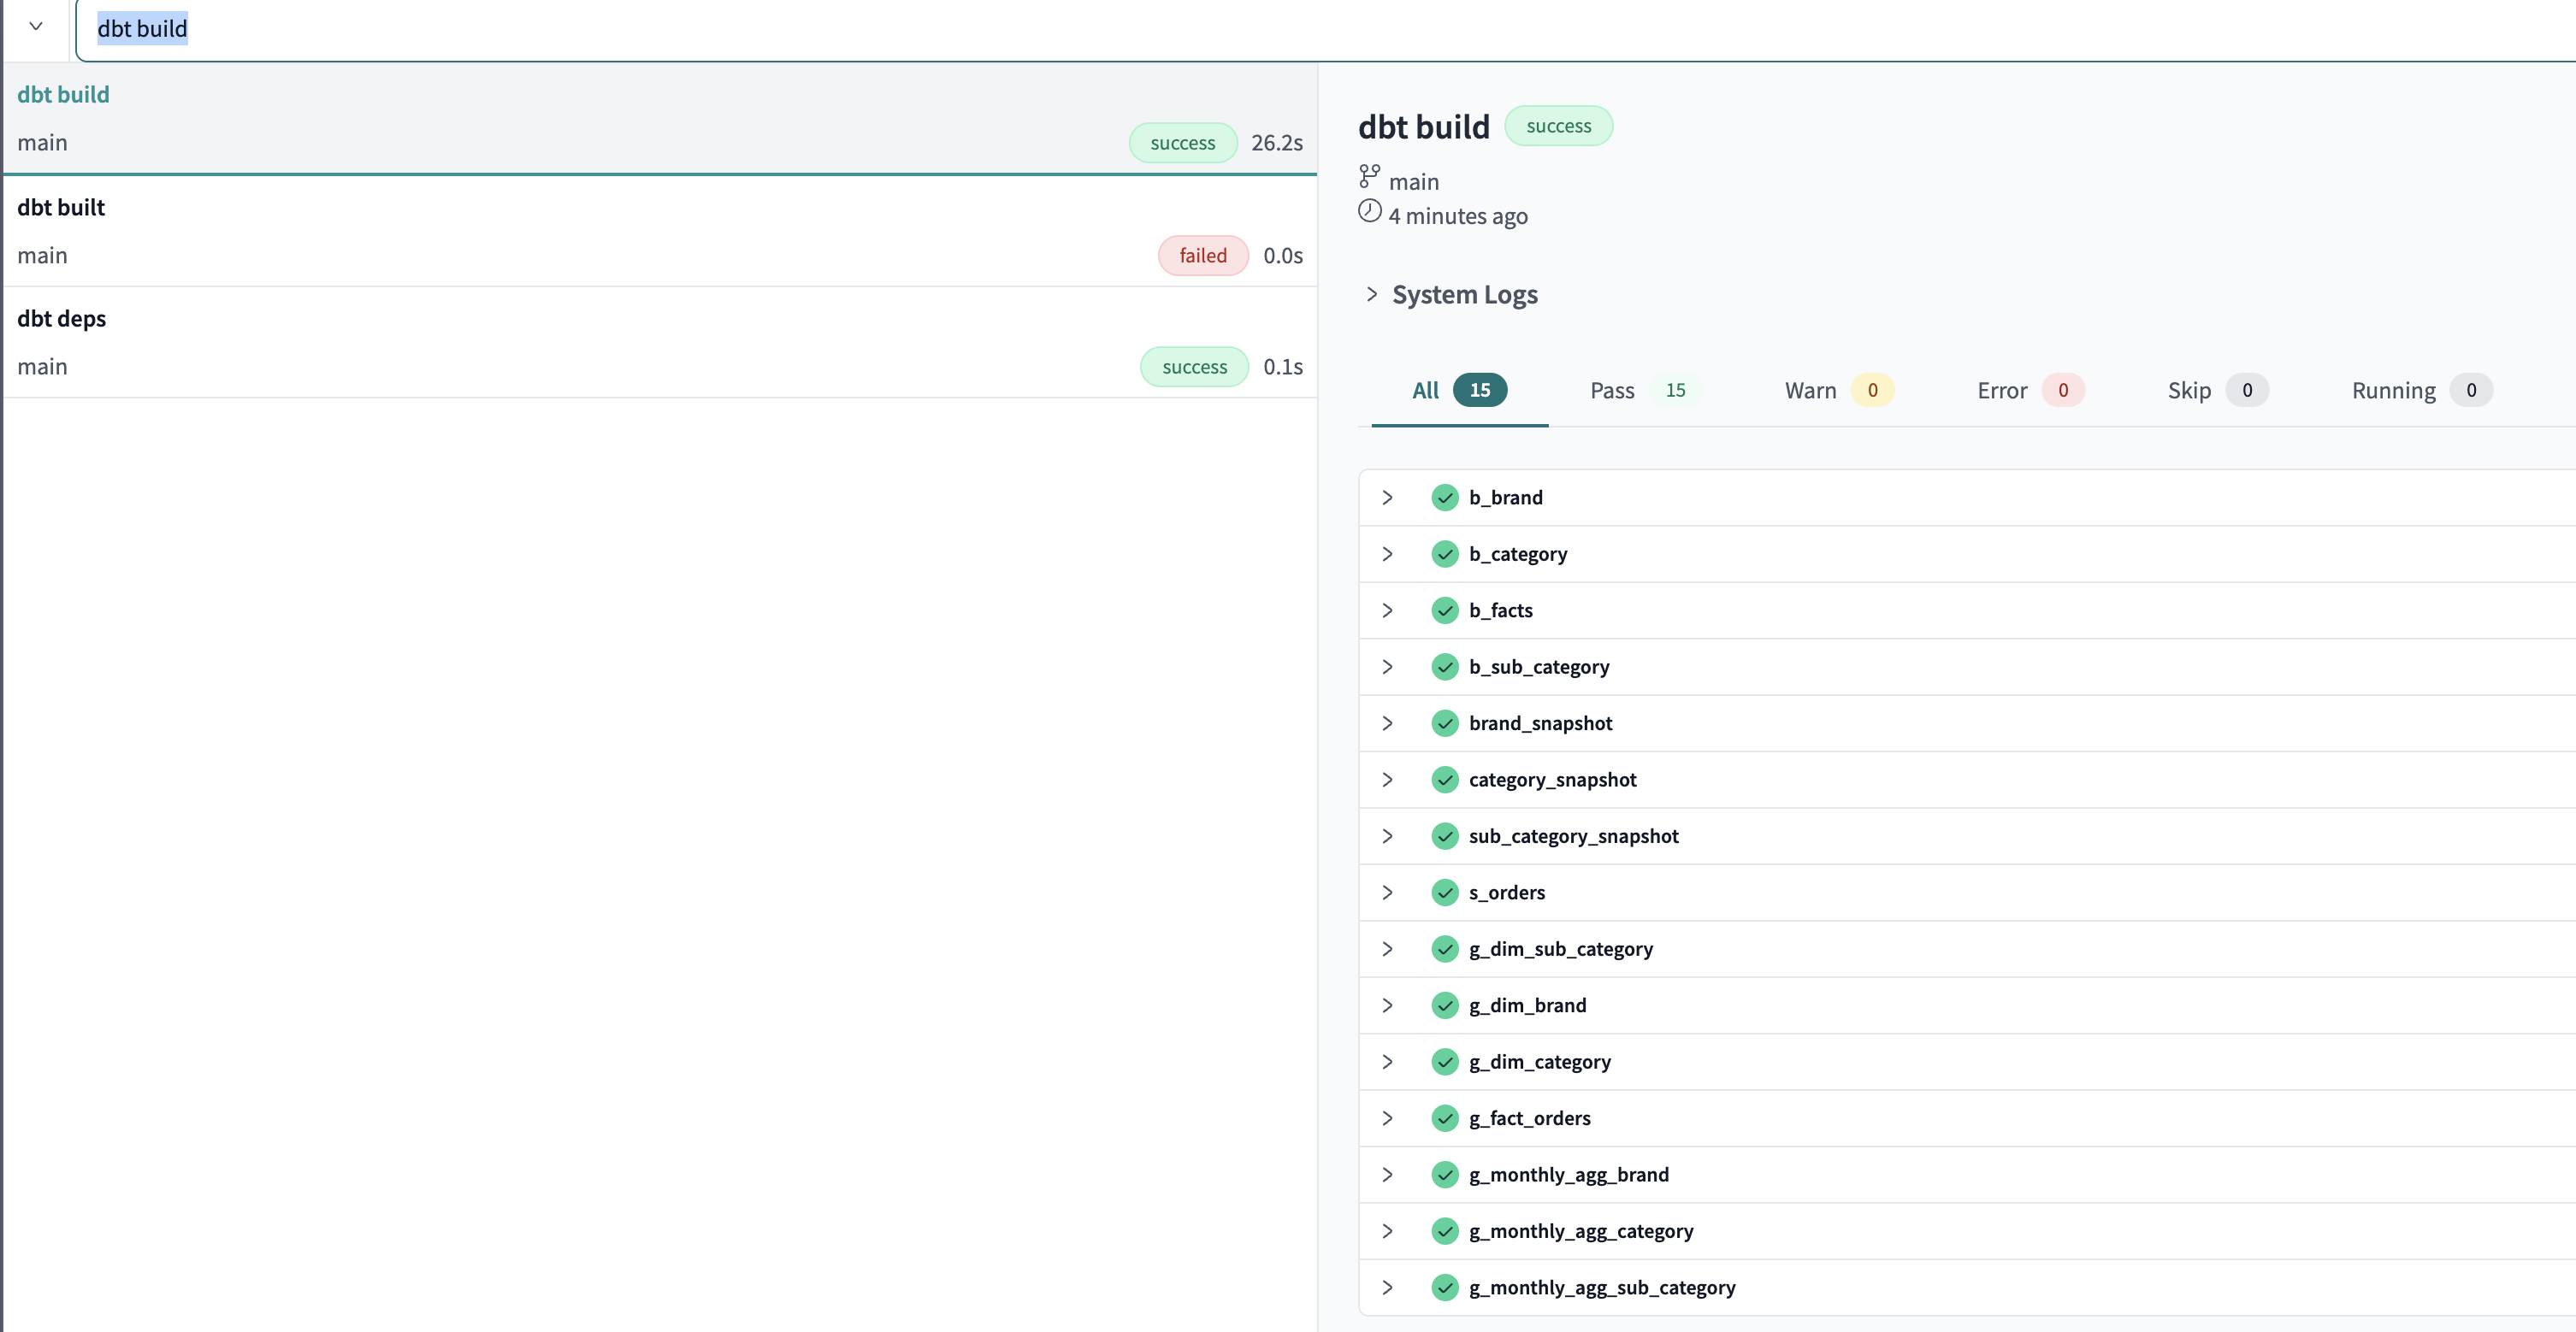

**[6.5]** On DBeaver, check that these 3 views have been correctly created:

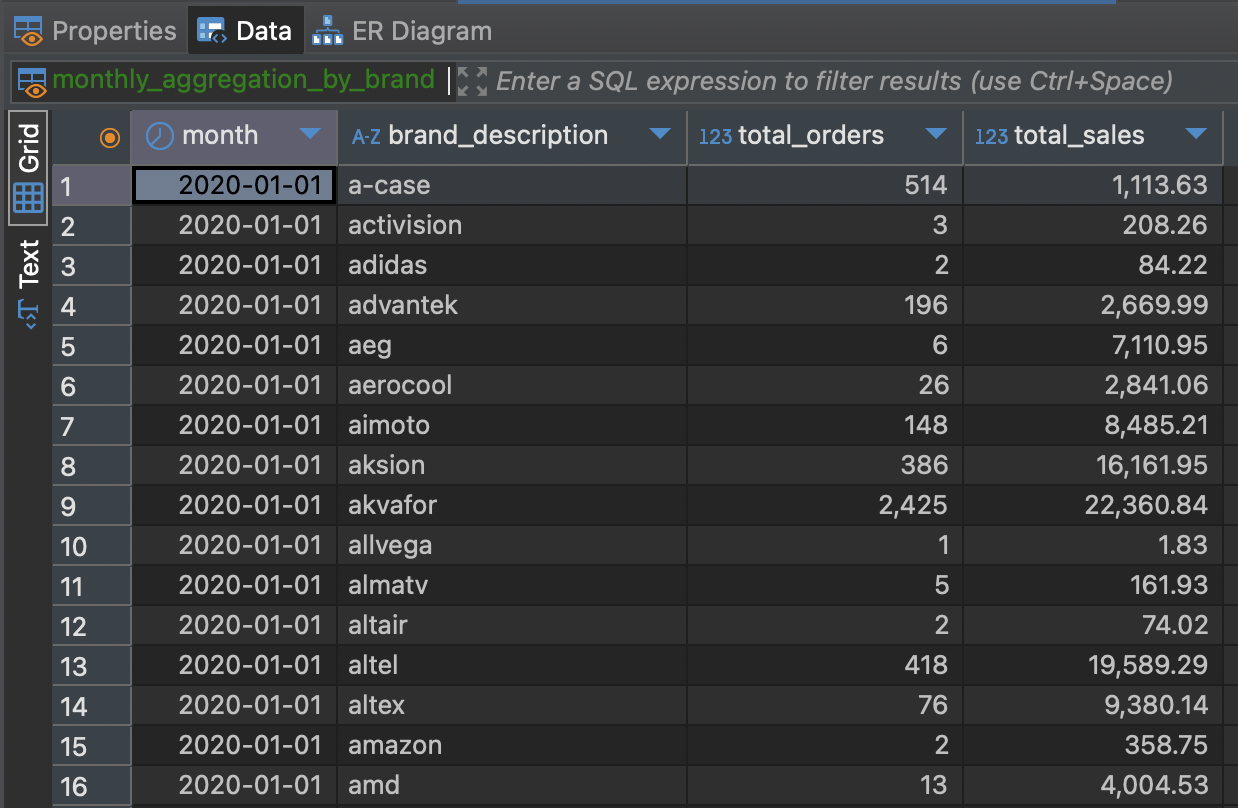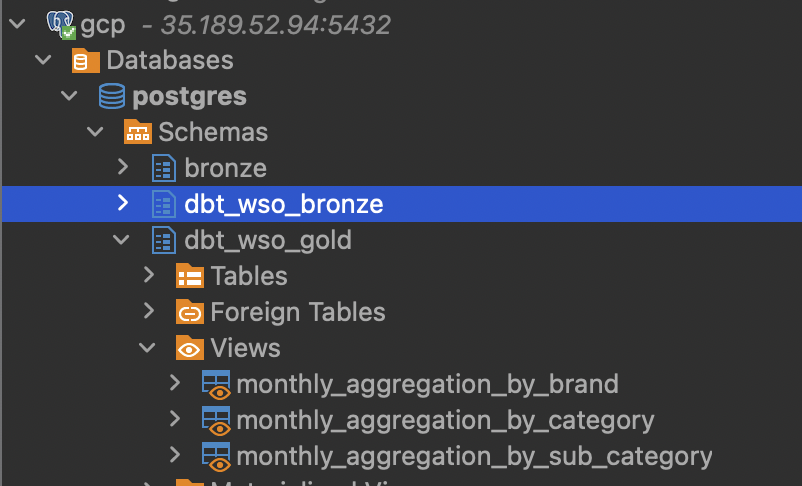

# 7. Deploy the dbt job

**[7.1]** On Dbt Cloud, go to `Deploy` then `Environment` and create a new environment with:





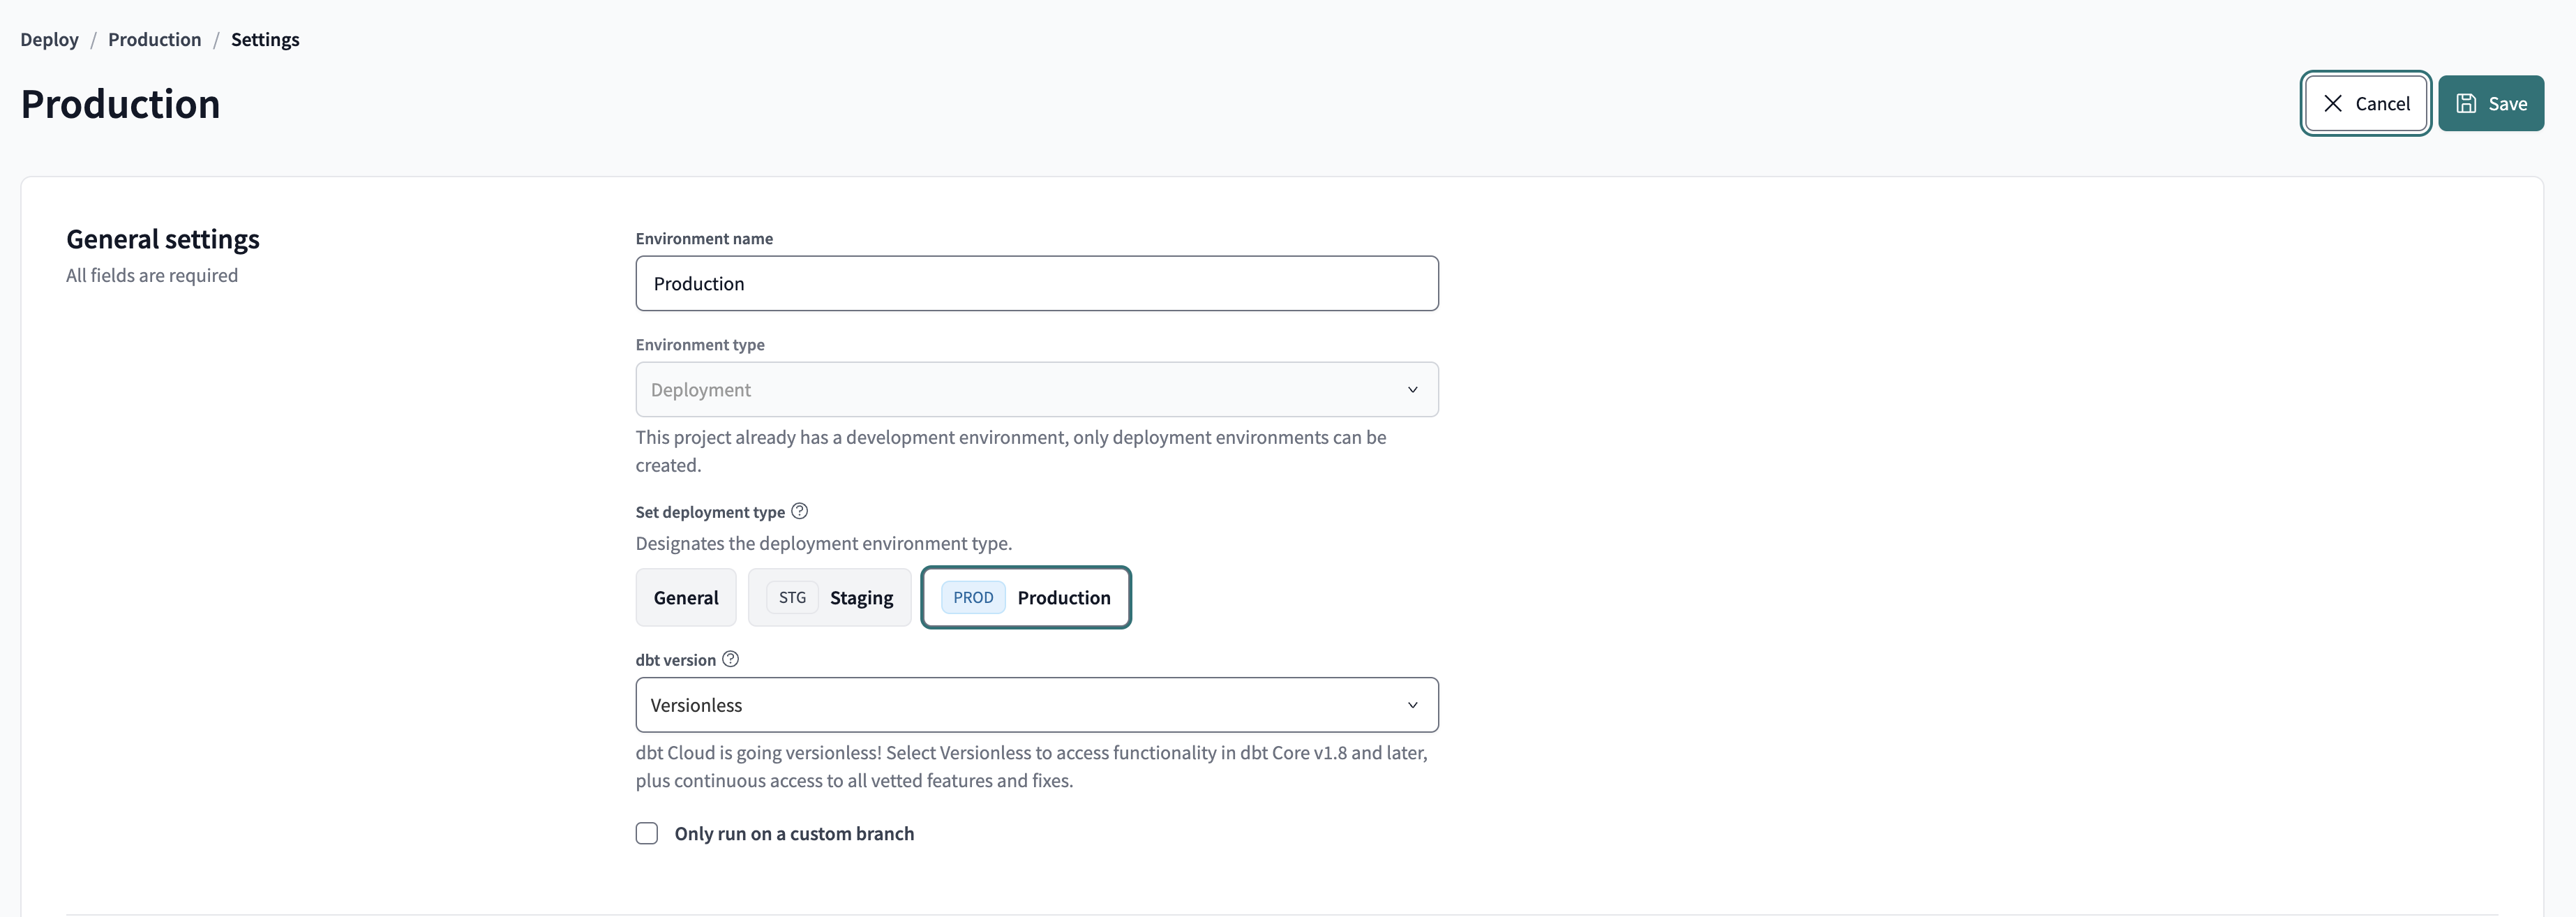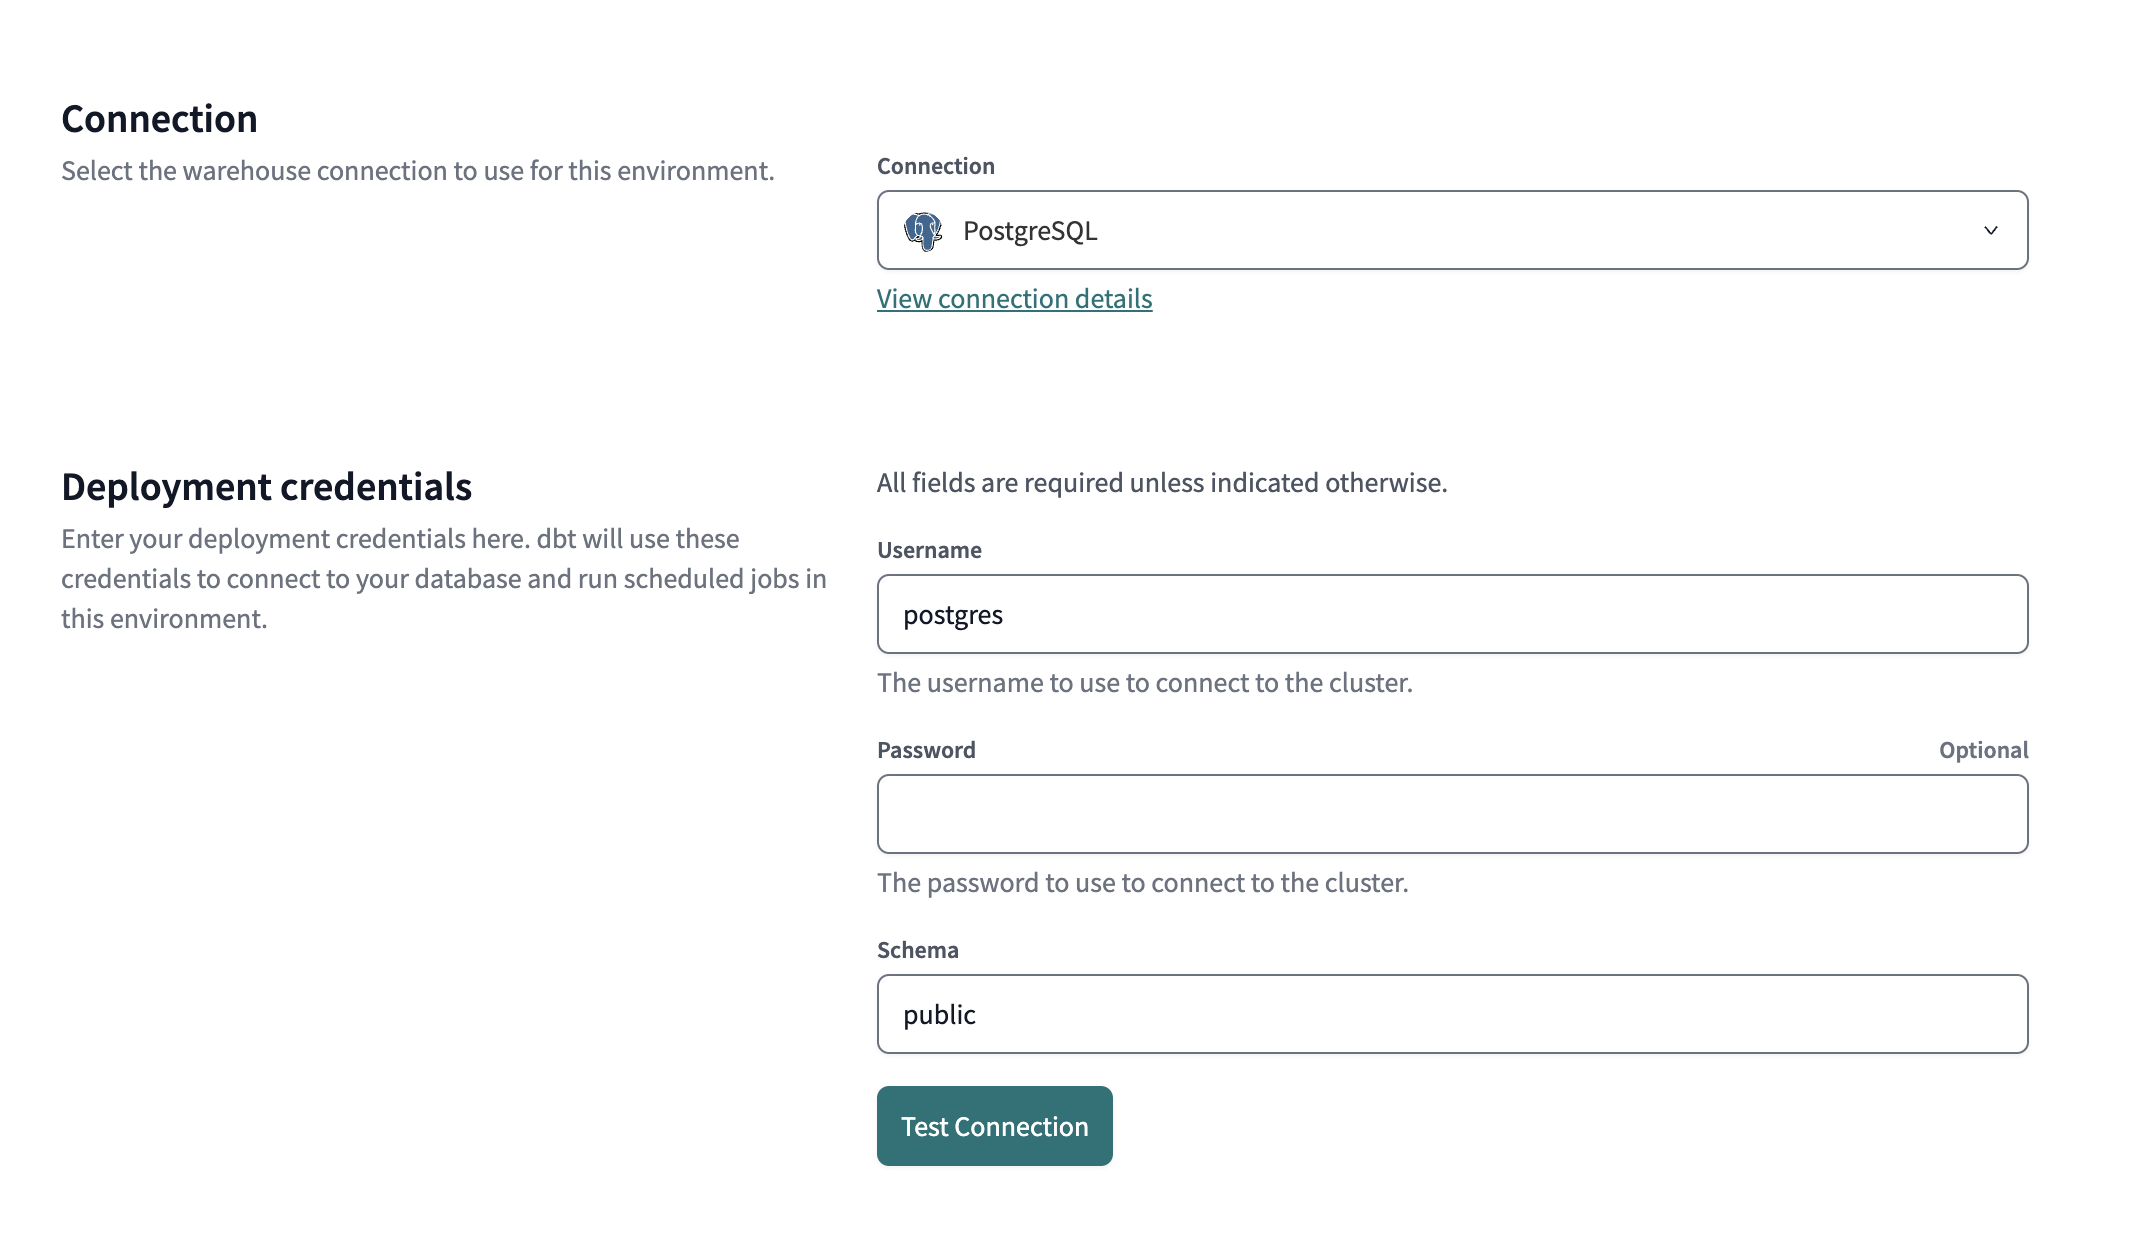

**[7.2]** Go to `Deploy` then `Jobs` and create a new job with:





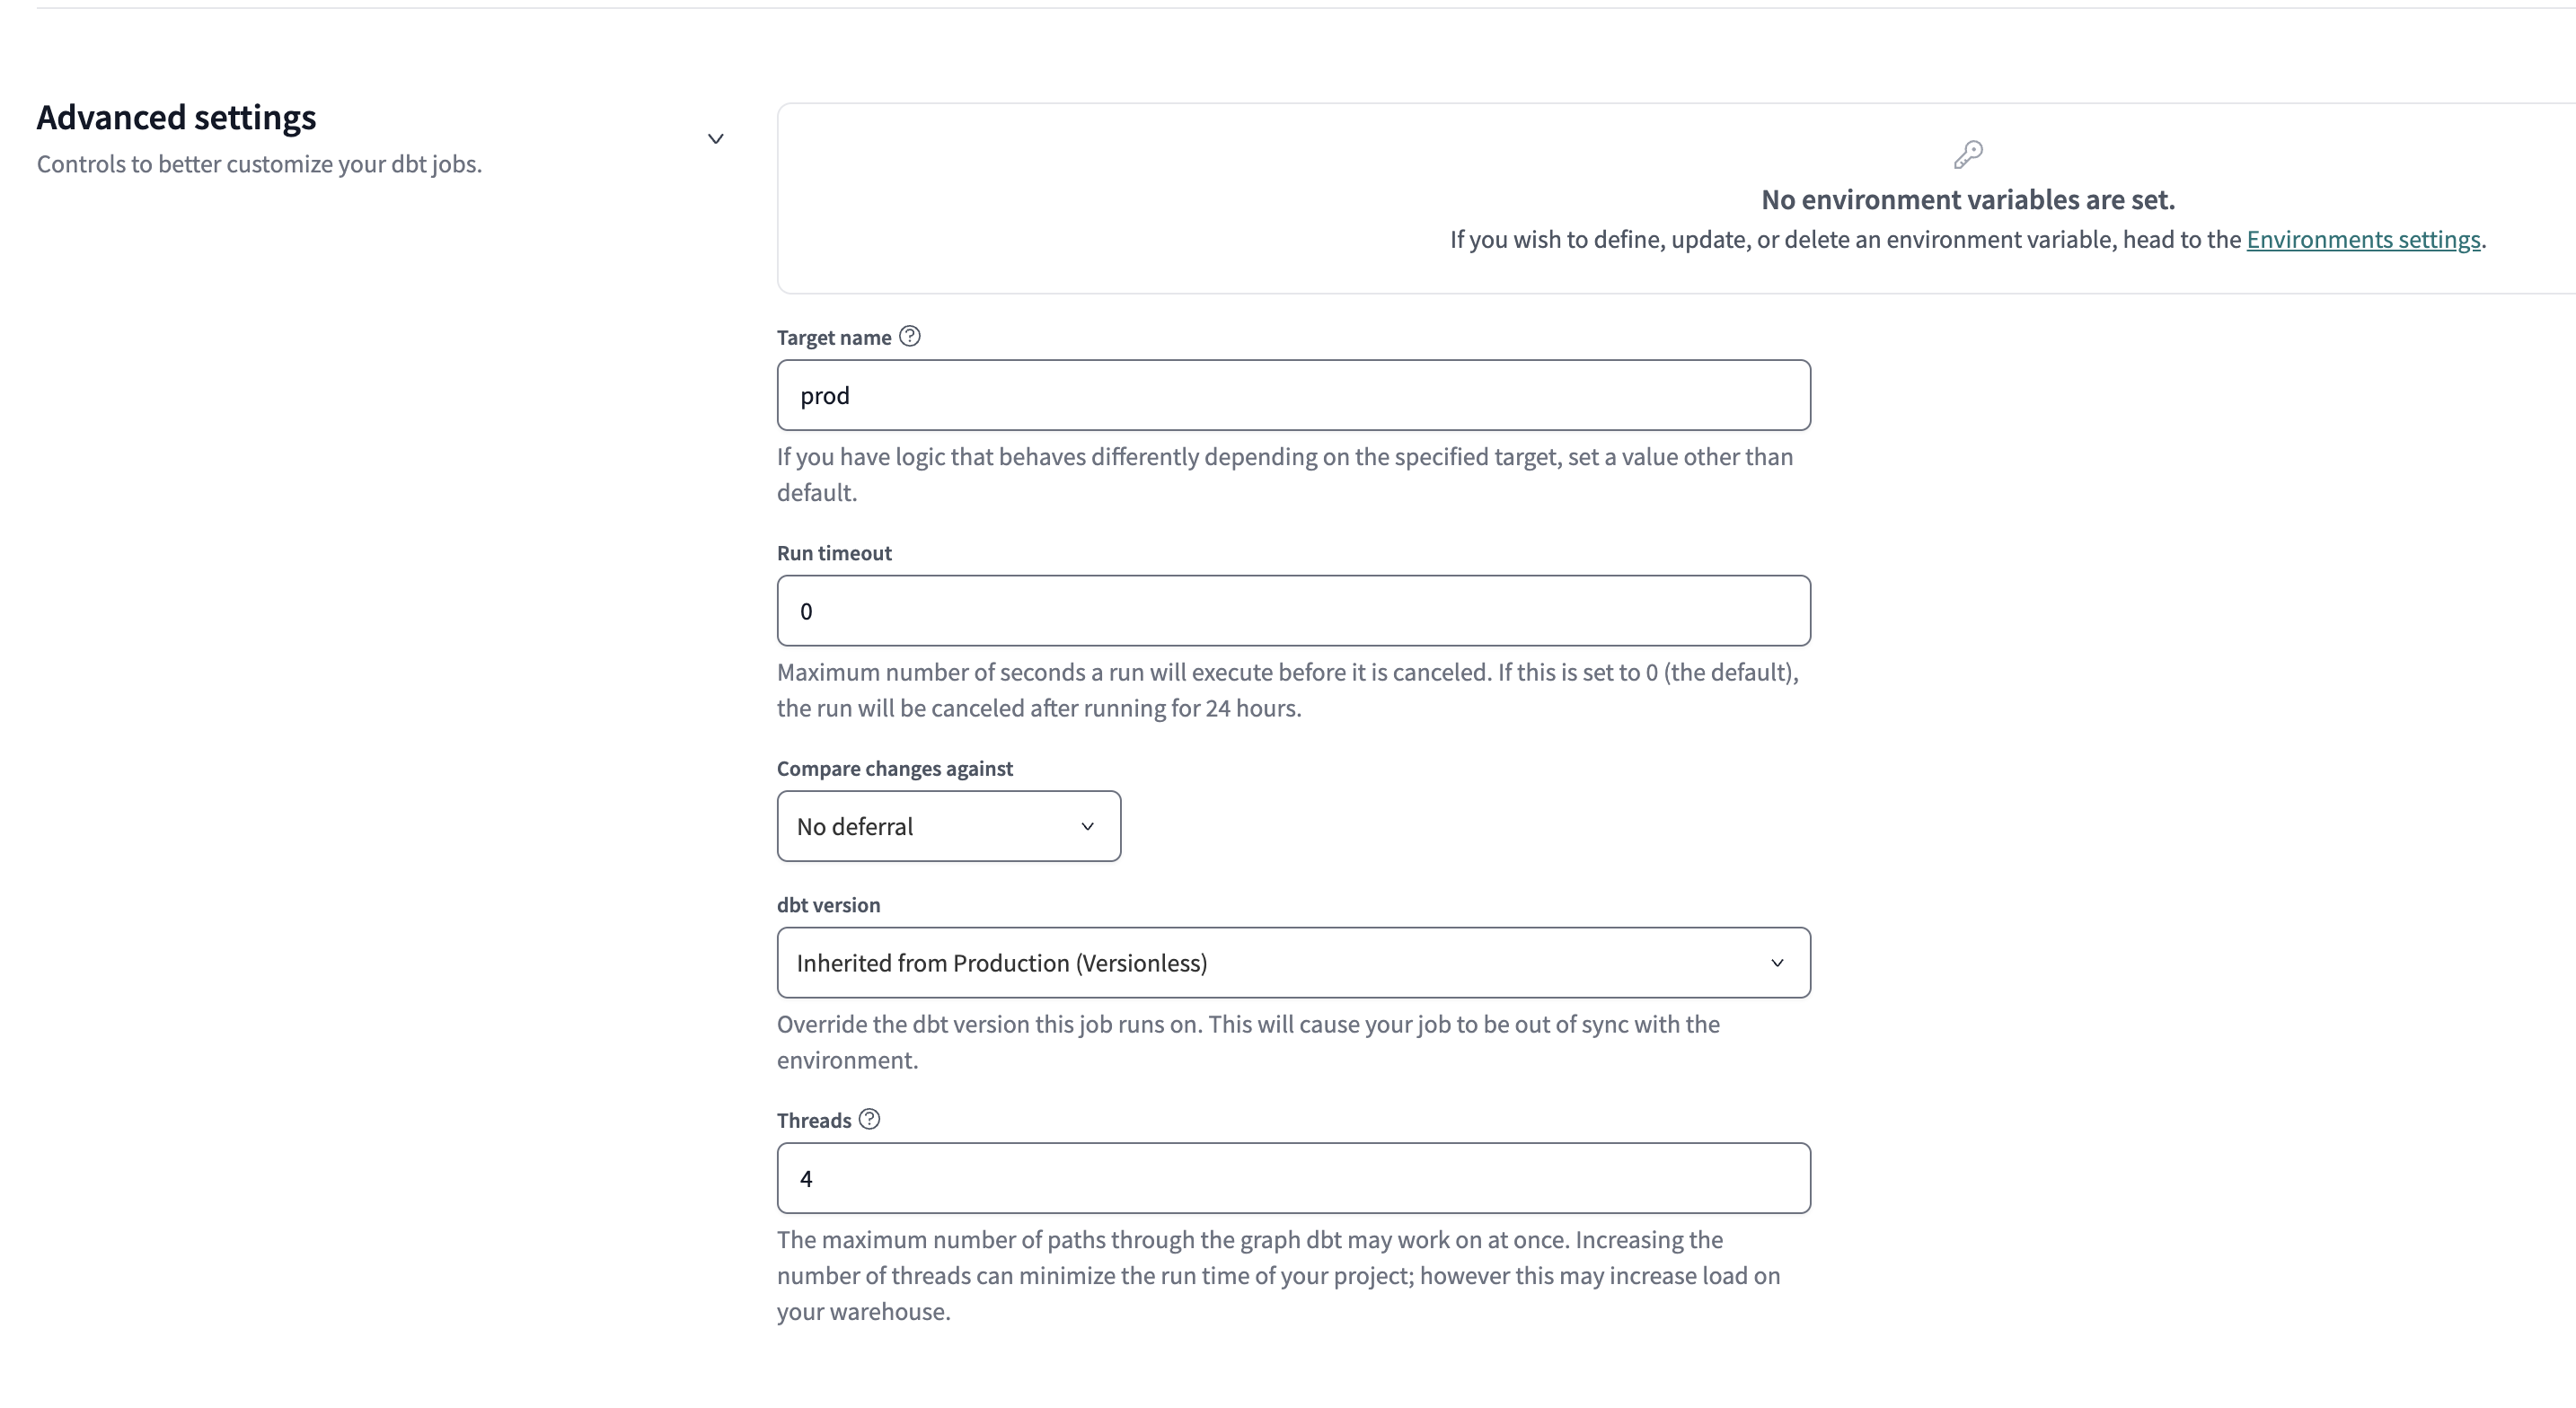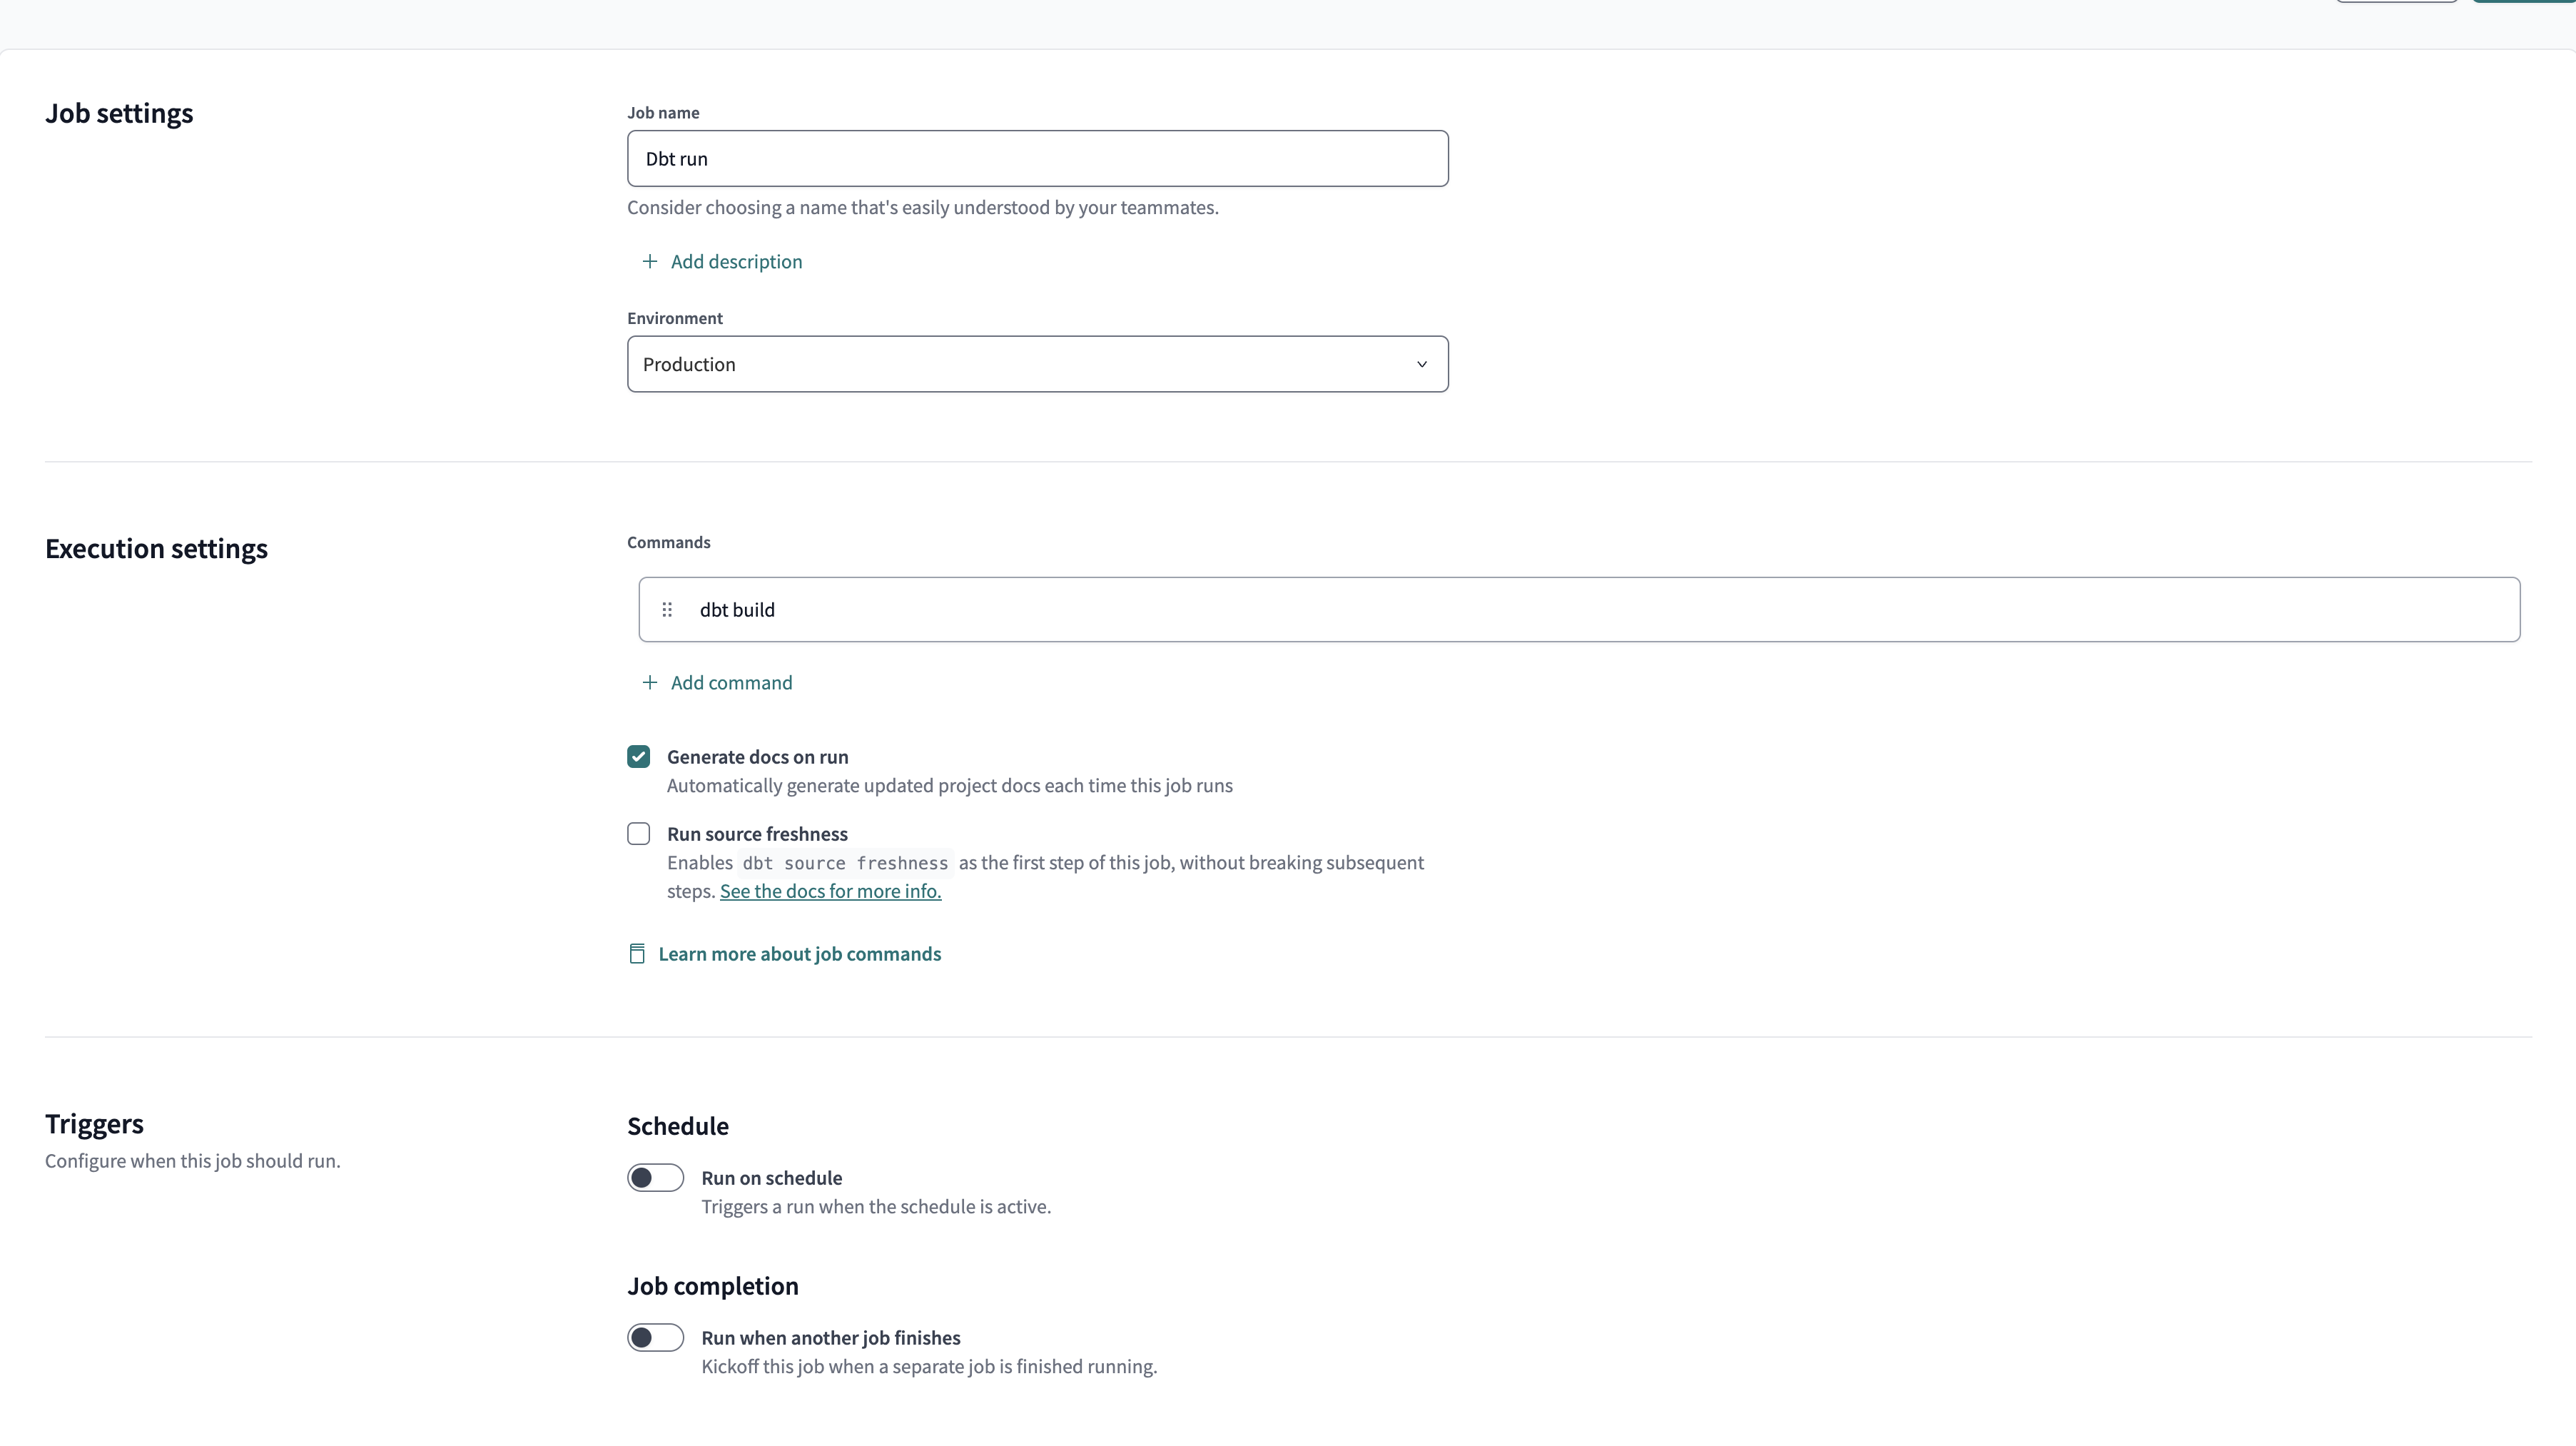

**[7.3]** Go to the job you just created and trigger it to run now:





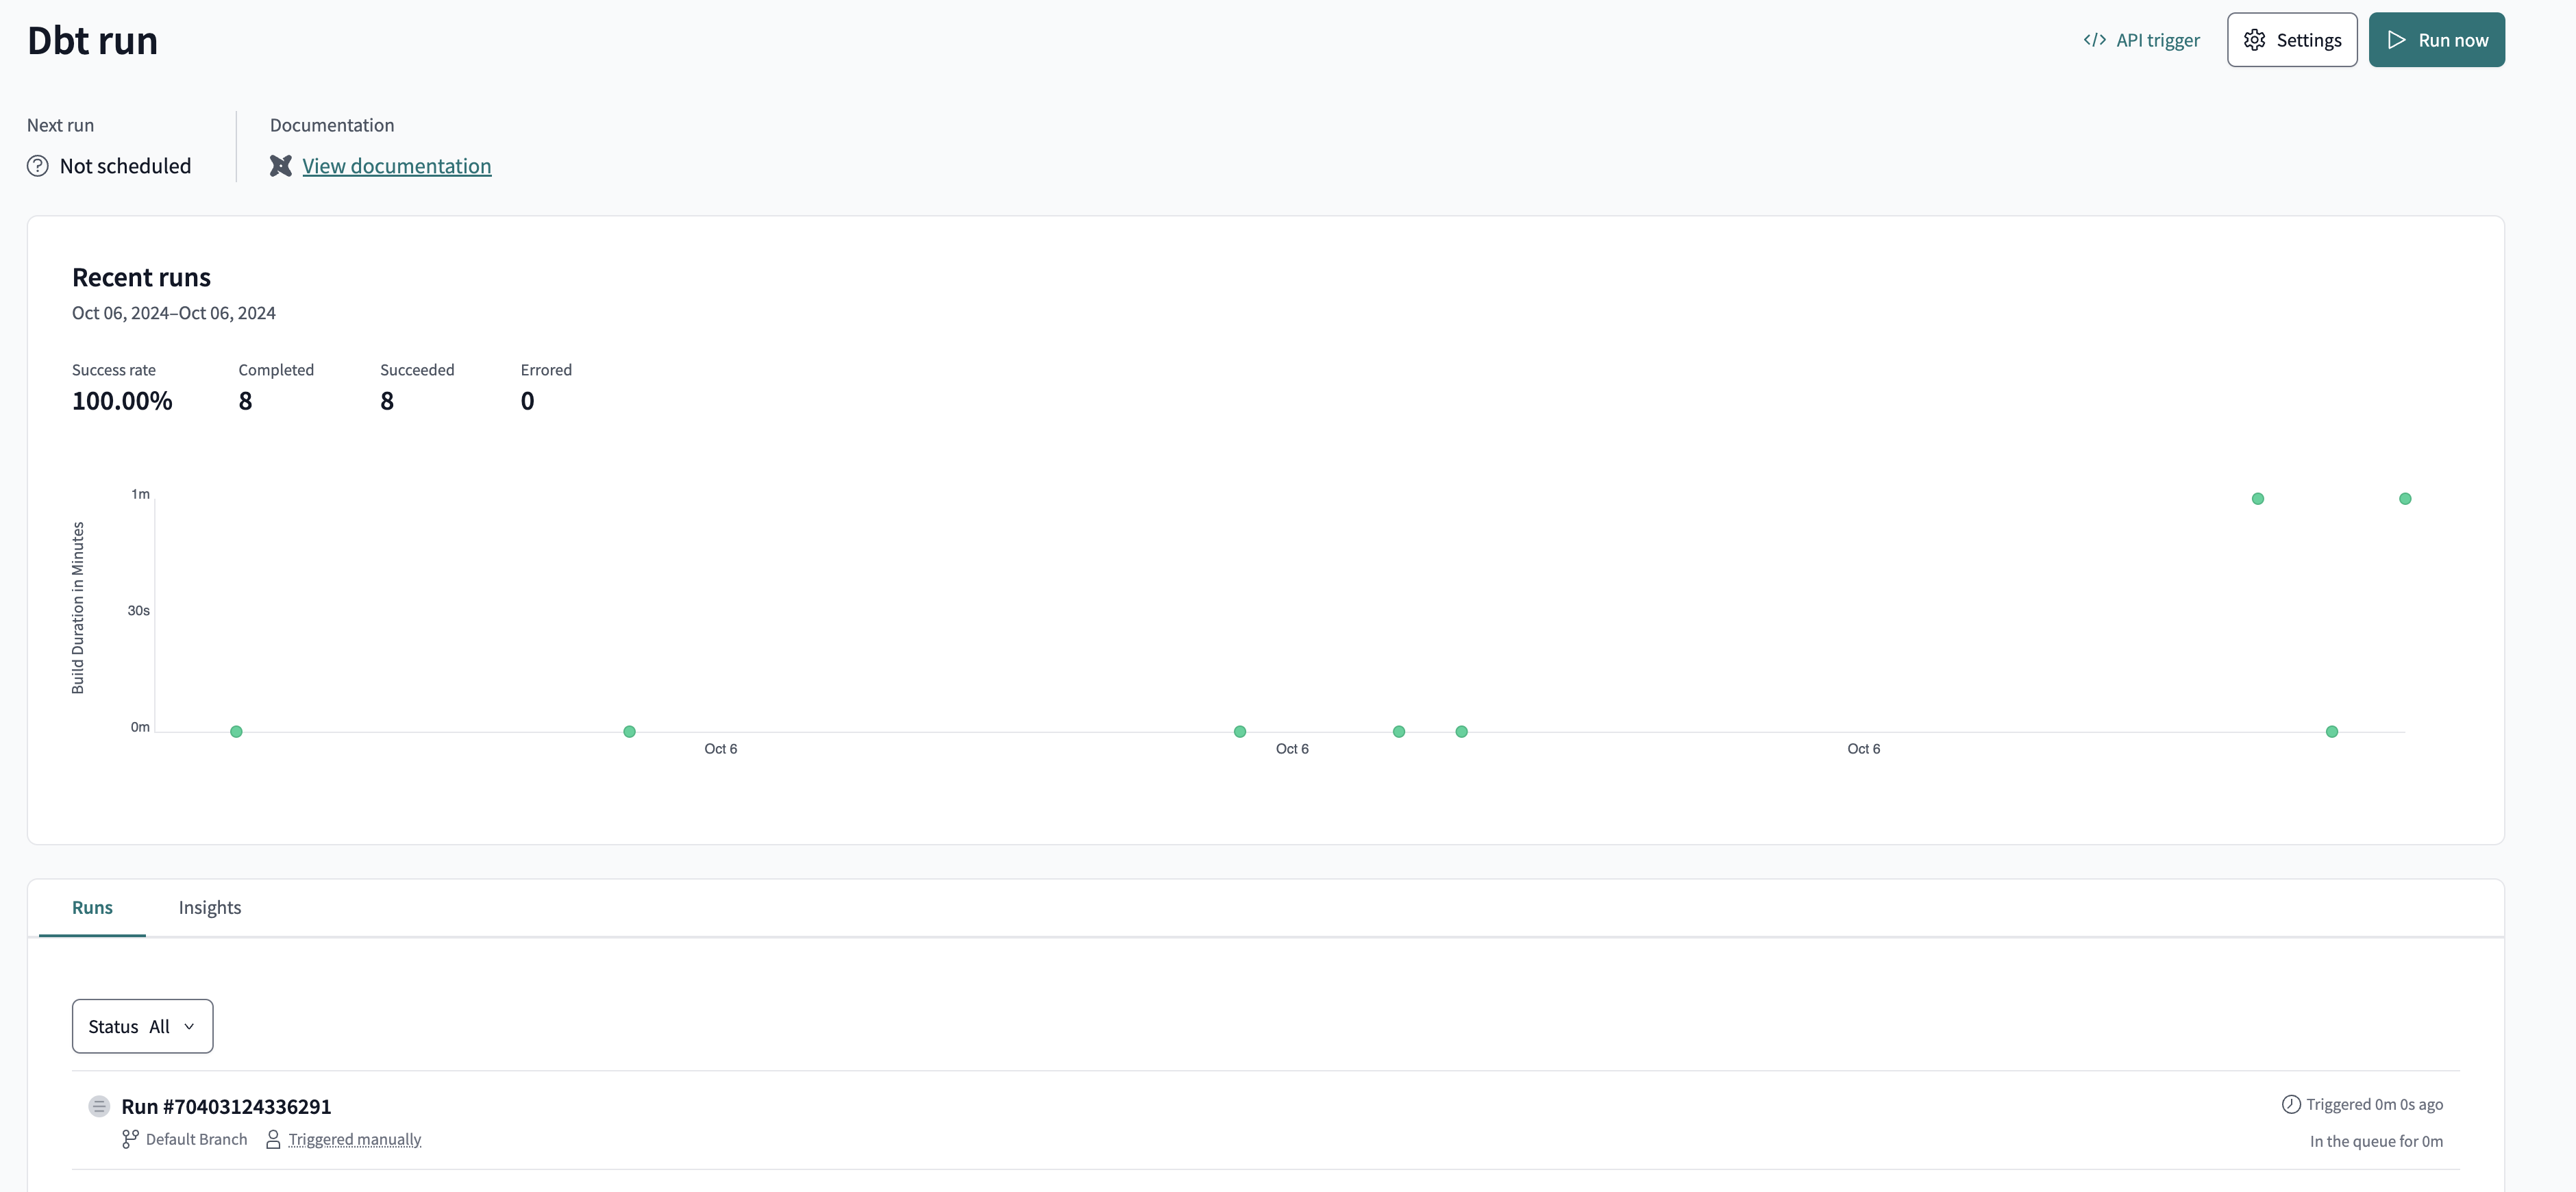

**[7.4]** On DBeaver, check that the production schemas with the tables and views have been correctly created

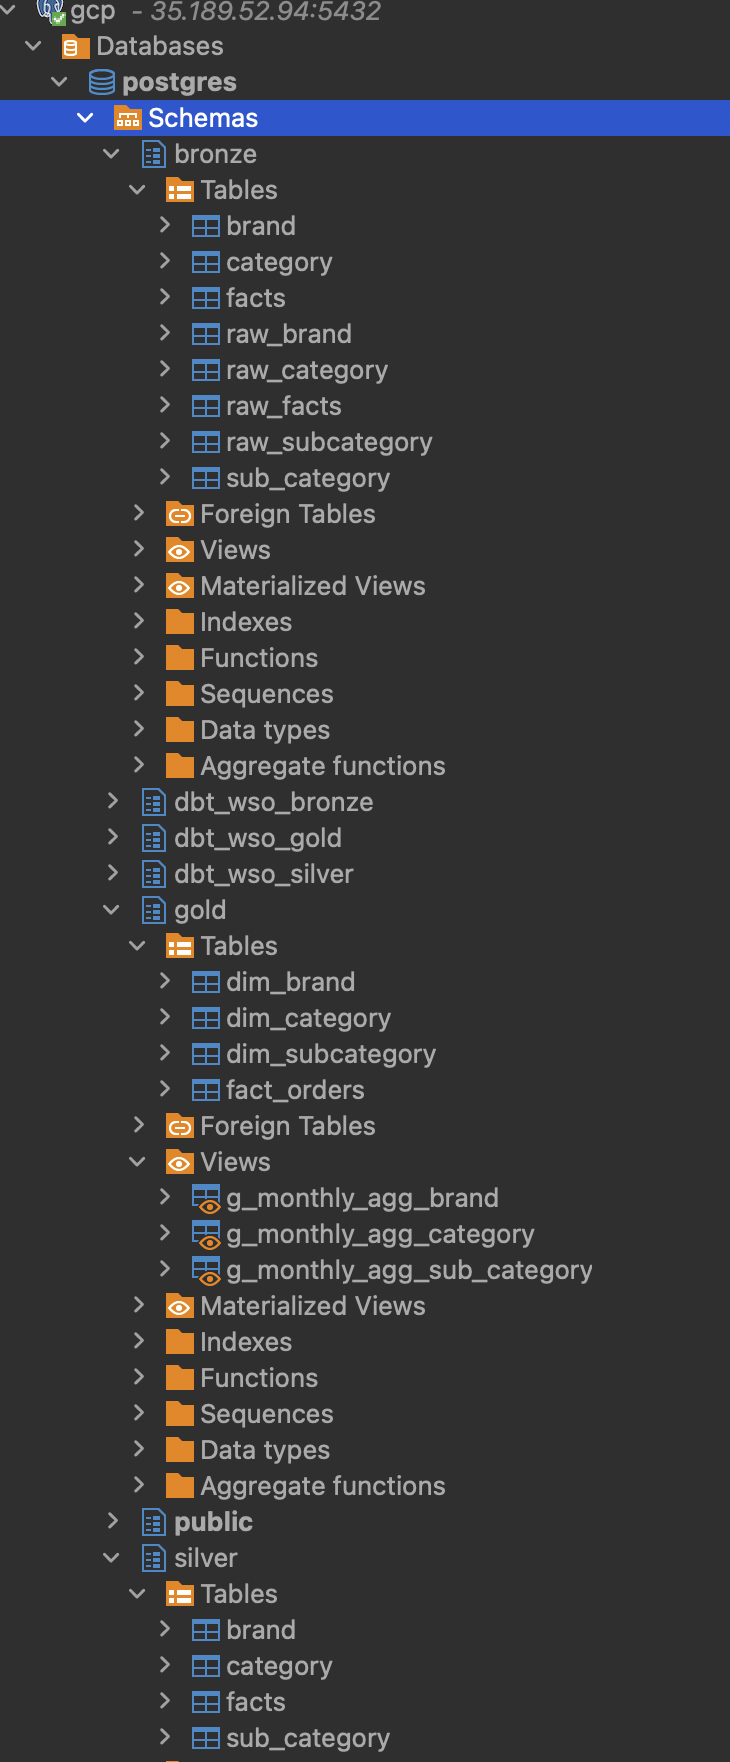

**[7.5]** On Dbt Cloud, go back to your job and click on API Trigger to retrive your `Account ID`, `Job ID` and the URL part between `https://` and `/api` and replace the `/` with `.` (in my case it is `nm505.us1.dbt.com`)

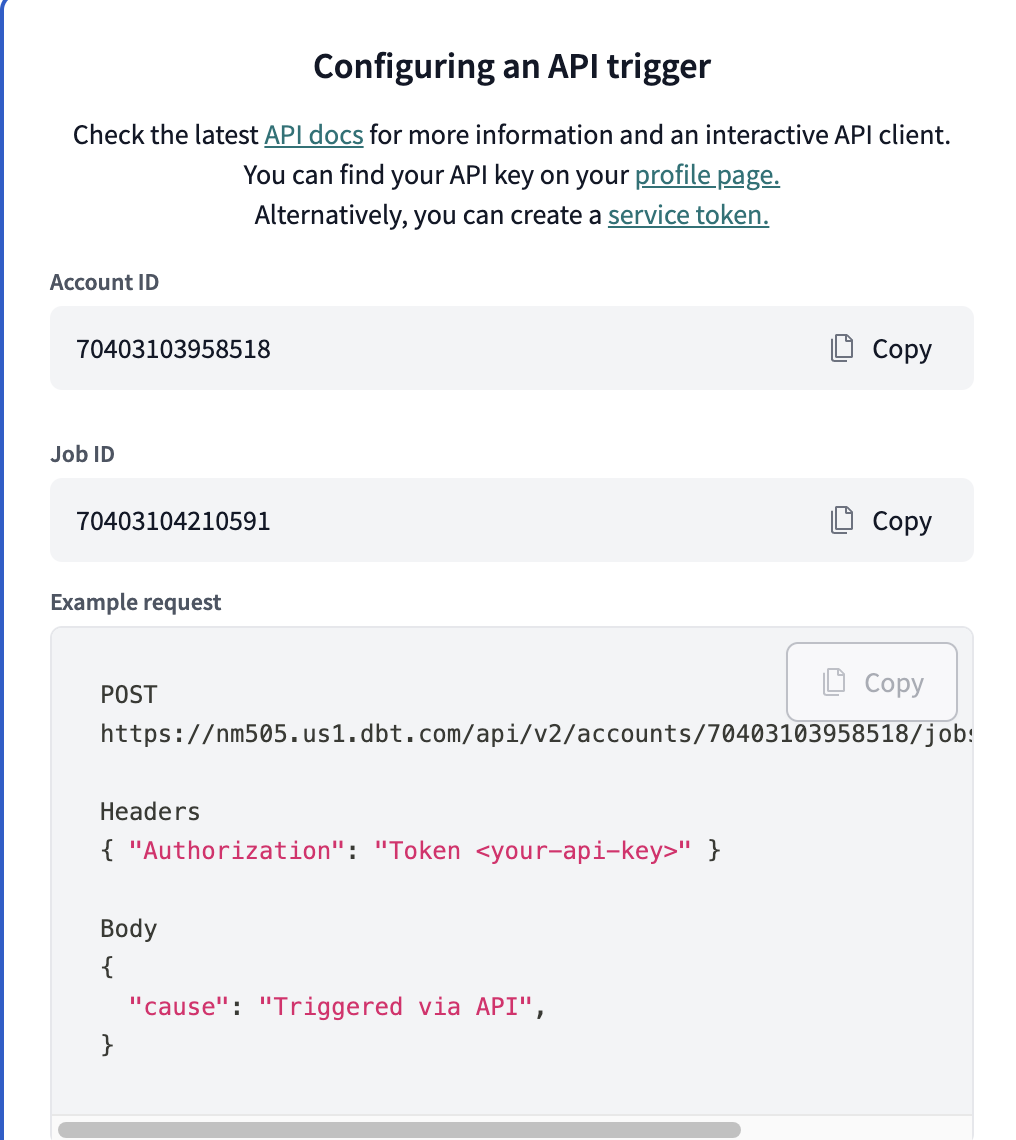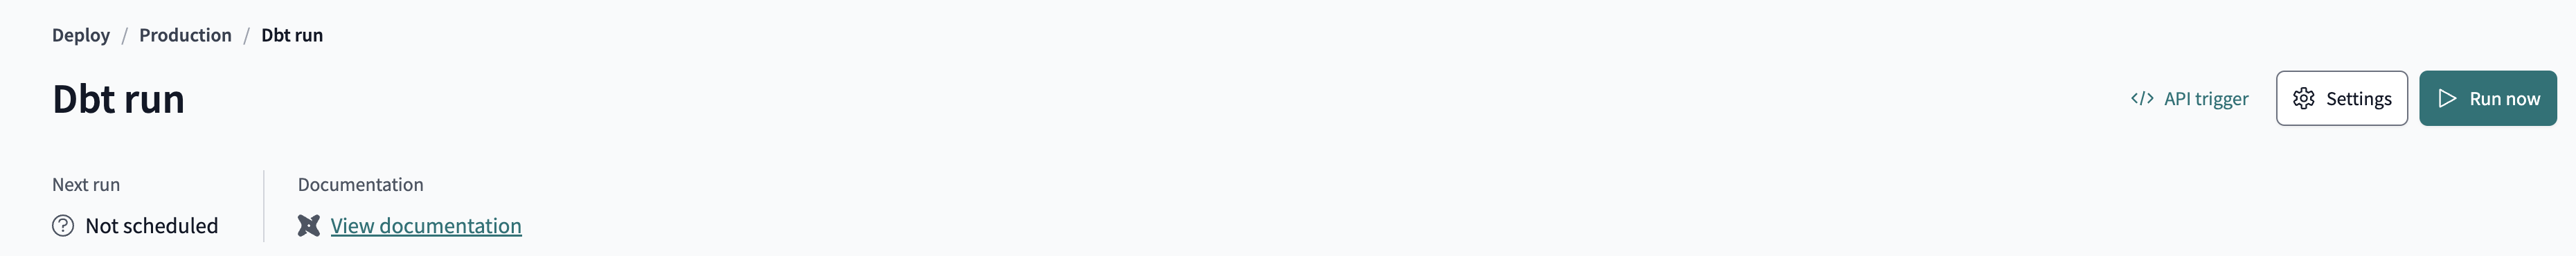

# 8. Orchestrate the dbt job with Airflow

**[8.1]** On Dbt Cloud, go to Account Settings then create a personal access token:

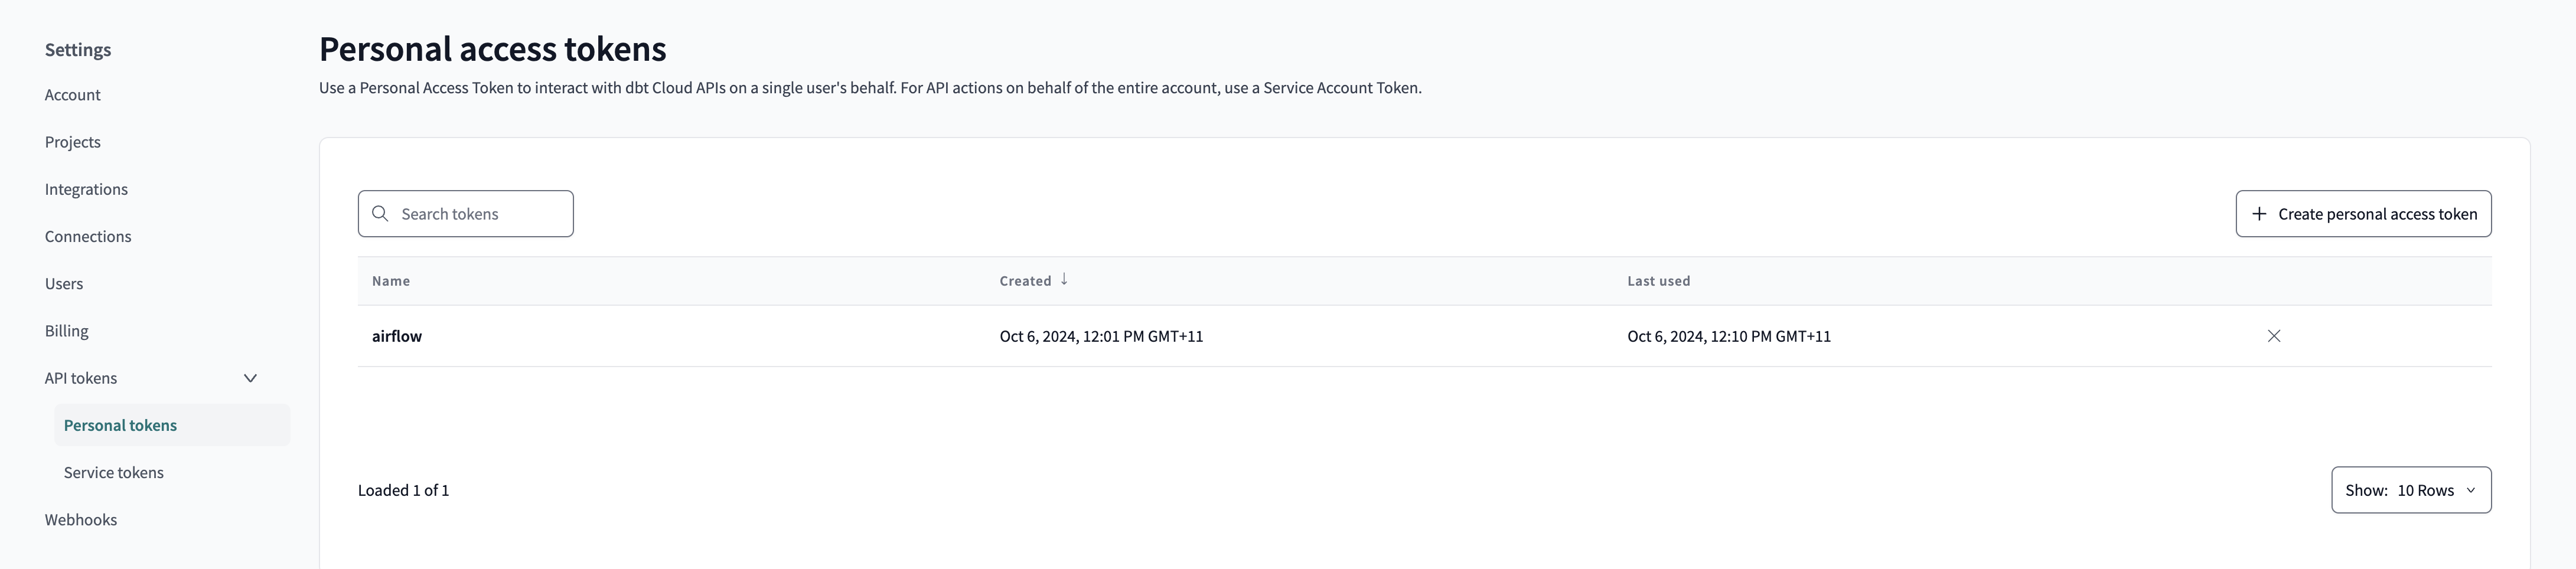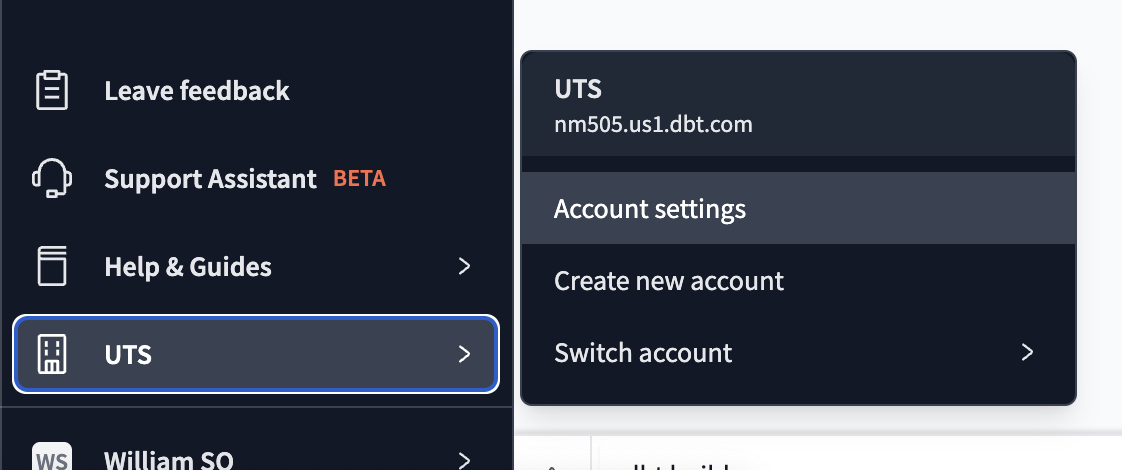

**[8.2]** On Airflow, add the following 4 variables with the values from your Dbt Cloud account:


1.   DBT_CLOUD_API_TOKEN
2.   DBT_CLOUD_ACCOUNT_ID
3.   DBT_CLOUD_JOB_ID
4.   DBT_CLOUD_URL

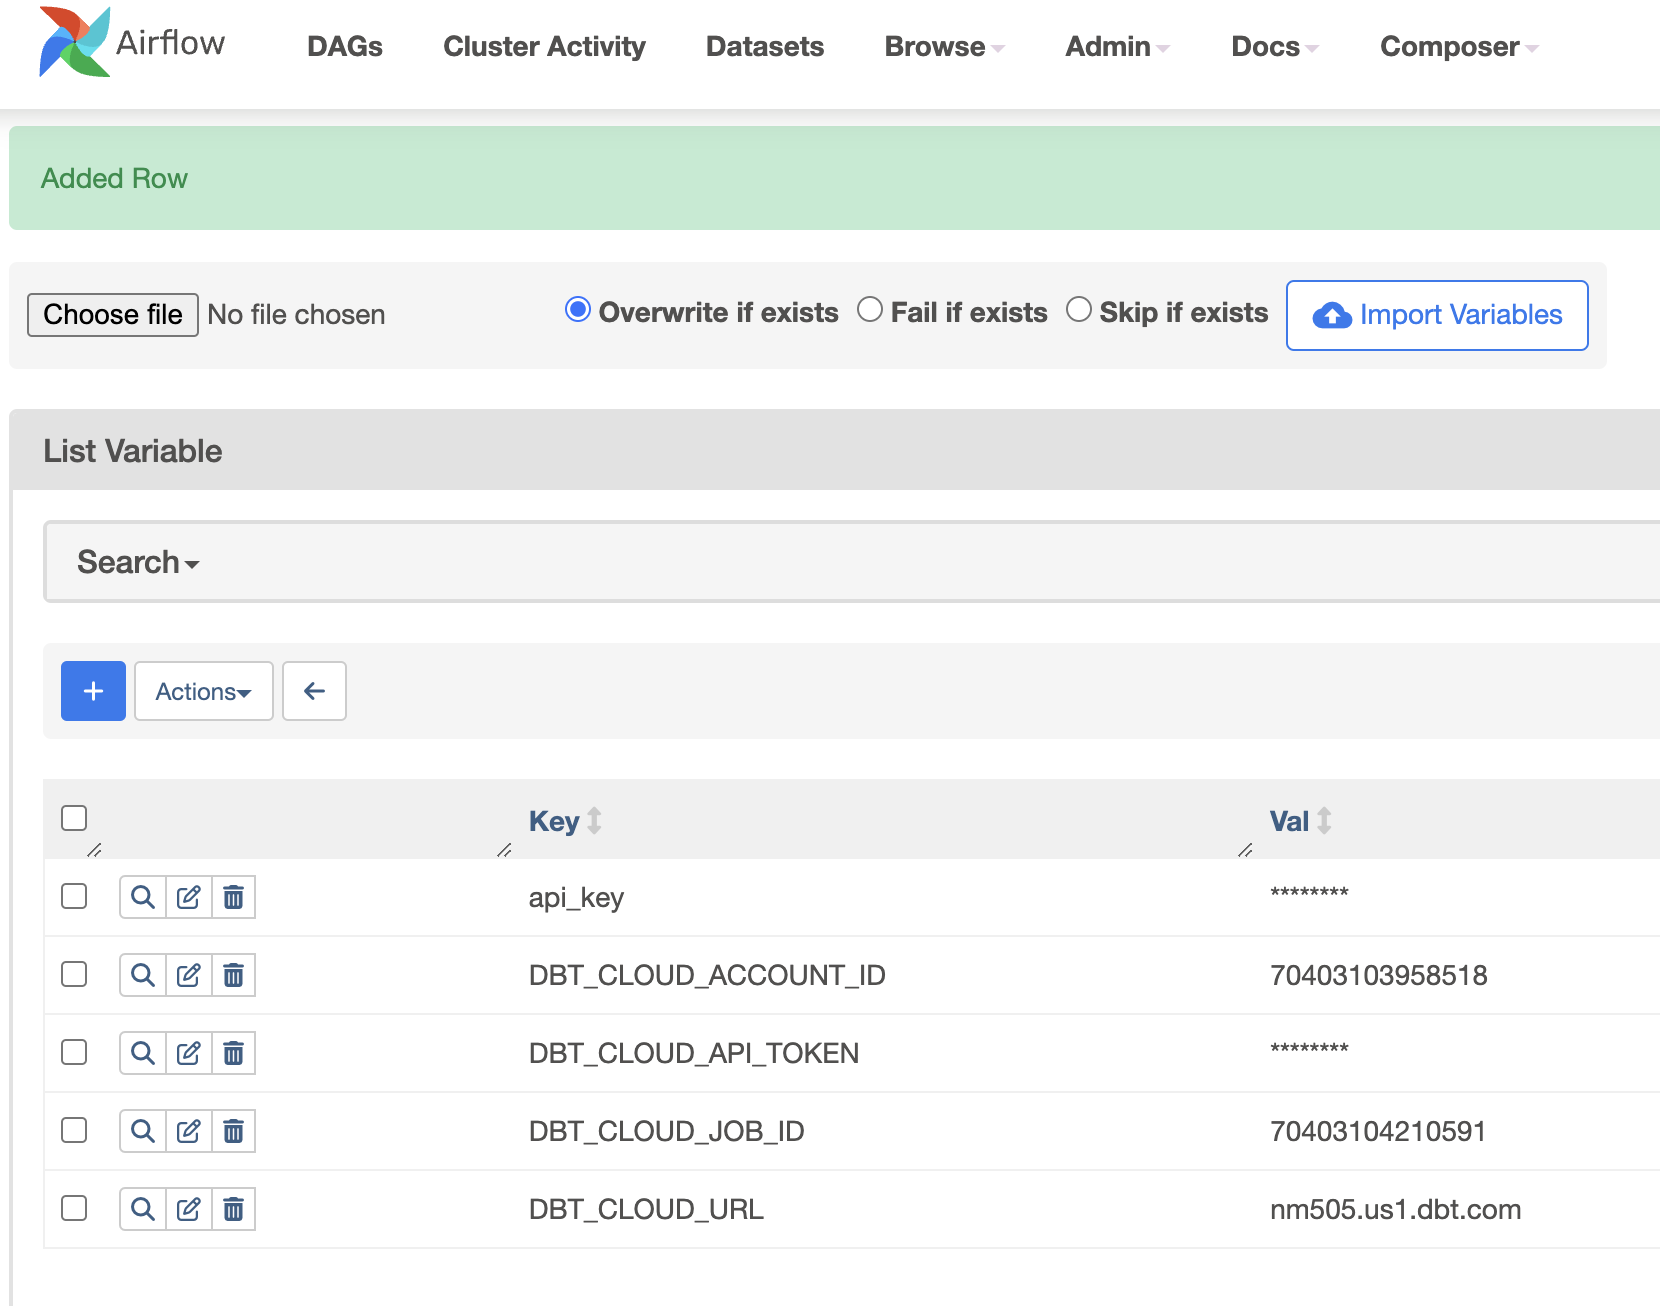

**[8.3]** Replace your dag with this new code which now includes a step to trigger your dbt job:

In [ ]:
import os
import logging
import requests
import pandas as pd
import shutil
from datetime import datetime, timedelta
from psycopg2.extras import execute_values
from airflow import AirflowException
from airflow import DAG
from airflow.operators.python_operator import PythonOperator
from airflow.providers.postgres.hooks.postgres import PostgresHook
from airflow.models import Variable

#########################################################
#
#   DAG Settings
#
#########################################################

dag_default_args = {
    'owner': 'BDE_LAB_6',
    'start_date': datetime.now() - timedelta(days=2+4),
    'email': [],
    'email_on_failure': True,
    'email_on_retry': False,
    'retries': 2,
    'retry_delay': timedelta(minutes=5),
    'depends_on_past': False,
    'wait_for_downstream': False,
}

dag = DAG(
    dag_id='exercise_3',
    default_args=dag_default_args,
    schedule_interval=None,
    catchup=True,
    max_active_runs=1,
    concurrency=5
)

#########################################################
#
#   Load Environment Variables
#
#########################################################
AIRFLOW_DATA = "/home/airflow/gcs/data"
DIMENSIONS = AIRFLOW_DATA + "/dimensions/"
FACTS = AIRFLOW_DATA + "/facts/"

#########################################################
#
#   Custom Logics for Operator
#
#########################################################

def import_load_dim_category_func(**kwargs):

    # Setup Postgres connection
    ps_pg_hook = PostgresHook(postgres_conn_id="postgres")
    conn_ps = ps_pg_hook.get_conn()

    # Check if the file exists
    category_file_path = DIMENSIONS + 'category.csv'
    if not os.path.exists(category_file_path):
        logging.info("No category.csv file found.")
        return None

    # Generate dataframe by reading the CSV file
    df = pd.read_csv(category_file_path)

    if len(df) > 0:
        col_names = ['id', 'category']
        values = df[col_names].to_dict('split')['data']
        logging.info(values)

        insert_sql = """
                    INSERT INTO bronze.raw_category(id, category)
                    VALUES %s
                    """
        result = execute_values(conn_ps.cursor(), insert_sql, values, page_size=len(df))
        conn_ps.commit()

        # Move the processed file to the archive folder
        archive_folder = os.path.join(DIMENSIONS, 'archive')
        if not os.path.exists(archive_folder):
            os.makedirs(archive_folder)
        shutil.move(category_file_path, os.path.join(archive_folder, 'category.csv'))
    return None


def import_load_dim_sub_category_func(**kwargs):

    # Setup Postgres connection
    ps_pg_hook = PostgresHook(postgres_conn_id="postgres")
    conn_ps = ps_pg_hook.get_conn()

    # Check if the file exists
    sub_category_file_path = DIMENSIONS + 'sub_category.csv'
    if not os.path.exists(sub_category_file_path):
        logging.info("No sub_category.csv file found.")
        return None

    # Generate dataframe by reading the CSV file
    df = pd.read_csv(sub_category_file_path)

    if len(df) > 0:
        col_names = ['id', 'sub_category']
        values = df[col_names].to_dict('split')['data']
        logging.info(values)

        insert_sql = """
                    INSERT INTO bronze.raw_subcategory(id, sub_category)
                    VALUES %s
                    """
        result = execute_values(conn_ps.cursor(), insert_sql, values, page_size=len(df))
        conn_ps.commit()

        # Move the processed file to the archive folder
        archive_folder = os.path.join(DIMENSIONS, 'archive')
        if not os.path.exists(archive_folder):
            os.makedirs(archive_folder)
        shutil.move(sub_category_file_path, os.path.join(archive_folder, 'sub_category.csv'))
    return None


def import_load_dim_brand_func(**kwargs):

    # Setup Postgres connection
    ps_pg_hook = PostgresHook(postgres_conn_id="postgres")
    conn_ps = ps_pg_hook.get_conn()

    # Check if the file exists
    brand_file_path = DIMENSIONS + 'brand.csv'
    if not os.path.exists(brand_file_path):
        logging.info("No brand.csv file found.")
        return None

    # Generate dataframe by reading the CSV file
    df = pd.read_csv(brand_file_path)

    if len(df) > 0:
        col_names = ['id', 'brand']
        values = df[col_names].to_dict('split')['data']
        logging.info(values)

        insert_sql = """
                    INSERT INTO bronze.raw_brand(id, brand)
                    VALUES %s
                    """
        result = execute_values(conn_ps.cursor(), insert_sql, values, page_size=len(df))
        conn_ps.commit()

        # Move the processed file to the archive folder
        archive_folder = os.path.join(DIMENSIONS, 'archive')
        if not os.path.exists(archive_folder):
            os.makedirs(archive_folder)
        shutil.move(brand_file_path, os.path.join(archive_folder, 'brand.csv'))
    return None


def import_load_facts_func(**kwargs):

    # Setup Postgres connection
    ps_pg_hook = PostgresHook(postgres_conn_id="postgres")
    conn_ps = ps_pg_hook.get_conn()

    # Get all files with '.csv' extension in the FACTS directory
    filelist = [k for k in os.listdir(FACTS) if '.csv' in k]

    # Check if there are any files to process
    if len(filelist) == 0:
        logging.info("No CSV files found in the FACTS directory.")
        return None  # Exit gracefully if no files are found

    # Generate dataframe by combining all files
    df = pd.concat([pd.read_csv(os.path.join(FACTS, fname)) for fname in filelist], ignore_index=True)

    if len(df) > 0:
        col_names = ['date', 'order_id', 'category_id', 'subcategory_id', 'brand_id', 'price']
        values = df[col_names].to_dict('split')['data']
        logging.info(values)

        insert_sql = """
                    INSERT INTO bronze.raw_facts(date, order_id, category_id, subcategory_id, brand_id, price)
                    VALUES %s
                    """
        result = execute_values(conn_ps.cursor(), insert_sql, values, page_size=len(df))
        conn_ps.commit()

        # Move processed files to the archive folder
        archive_folder = os.path.join(FACTS, 'archive')
        if not os.path.exists(archive_folder):
            os.makedirs(archive_folder)

        for fname in filelist:
            shutil.move(os.path.join(FACTS, fname), os.path.join(archive_folder, fname))
    return None

#########################################################
#
#   Function to trigger dbt Cloud Job
#
#########################################################

def trigger_dbt_cloud_job(**kwargs):
    # Get the dbt Cloud URL, account ID, and job ID from Airflow Variables
    dbt_cloud_url = Variable.get("DBT_CLOUD_URL")
    dbt_cloud_account_id = Variable.get("DBT_CLOUD_ACCOUNT_ID")
    dbt_cloud_job_id = Variable.get("DBT_CLOUD_JOB_ID")

    # Define the URL for the dbt Cloud job API dynamically using URL, account ID, and job ID
    url = f"https://{dbt_cloud_url}/api/v2/accounts/{dbt_cloud_account_id}/jobs/{dbt_cloud_job_id}/run/"

    # Get the dbt Cloud API token from Airflow Variables
    dbt_cloud_token = Variable.get("DBT_CLOUD_API_TOKEN")

    # Define the headers and body for the request
    headers = {
        'Authorization': f'Token {dbt_cloud_token}',
        'Content-Type': 'application/json'
    }
    data = {
        "cause": "Triggered via API"
    }

    # Make the POST request to trigger the dbt Cloud job
    response = requests.post(url, headers=headers, json=data)

    # Check if the response is successful
    if response.status_code == 200:
        logging.info("Successfully triggered dbt Cloud job.")
        return response.json()
    else:
        logging.error(f"Failed to trigger dbt Cloud job: {response.status_code}, {response.text}")
        raise AirflowException("Failed to trigger dbt Cloud job.")

#########################################################
#
#   DAG Operator Setup
#
#########################################################

import_load_dim_category_task = PythonOperator(
    task_id="import_load_dim_category_id",
    python_callable=import_load_dim_category_func,
    provide_context=True,
    dag=dag
)

import_load_dim_sub_category_task = PythonOperator(
    task_id="import_load_dim_sub_category_id",
    python_callable=import_load_dim_sub_category_func,
    provide_context=True,
    dag=dag
)

import_load_dim_brand_task = PythonOperator(
    task_id="import_load_dim_brand_id",
    python_callable=import_load_dim_brand_func,
    provide_context=True,
    dag=dag
)

import_load_facts_task = PythonOperator(
    task_id="import_load_facts_id",
    python_callable=import_load_facts_func,
    provide_context=True,
    dag=dag
)

trigger_dbt_job_task = PythonOperator(
    task_id='trigger_dbt_job',
    python_callable=trigger_dbt_cloud_job,
    provide_context=True,
    dag=dag
)

# Task Dependencies
[import_load_dim_category_task, import_load_dim_sub_category_task, import_load_dim_brand_task] >> import_load_facts_task >> trigger_dbt_job_task


**[8.4]** Load in your `facts` folder under `data` the `sales_202002.csv` file then trigger the Airflow dag. After the dad is completed check on DBeaver if the files was properly loaded and the dbt transformations has been performed too:

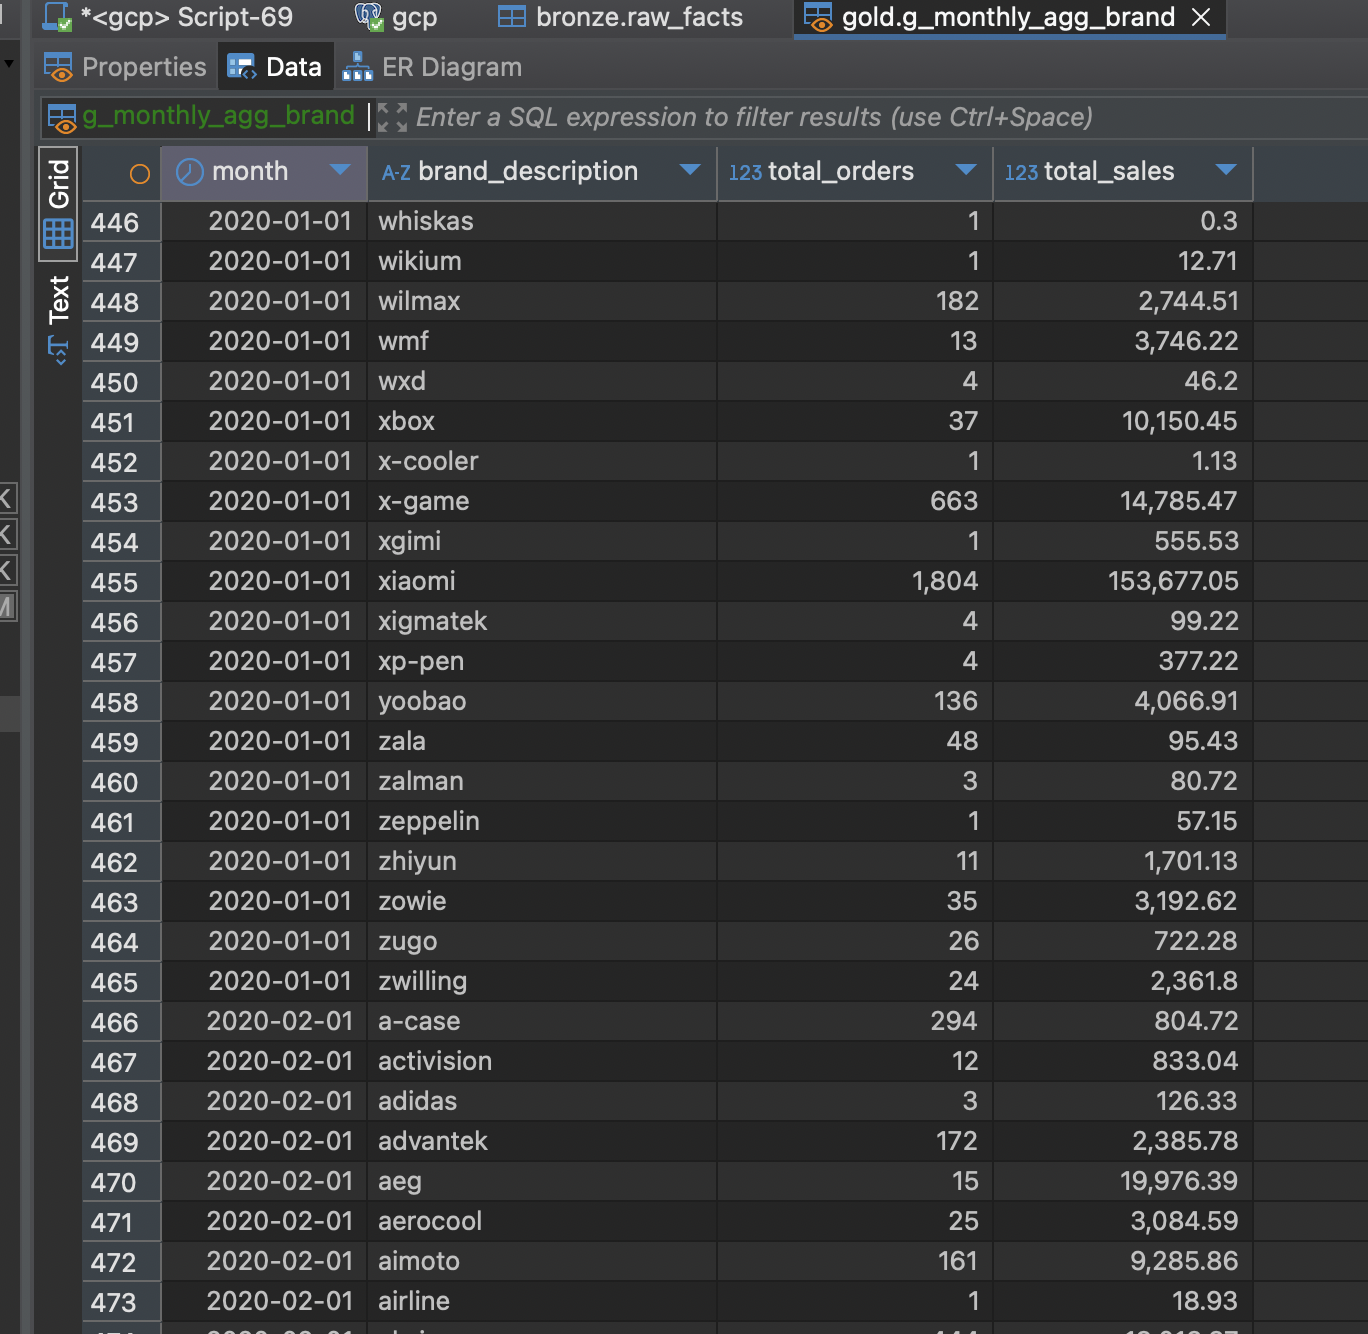